# Analysis of the resilience of the United-Kingdom train network : Application to freight trains

## Import libraries and data

## Libraries and functions

In [101]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import pandas as pd
import math
import geopandas as gpd
import networkx as nx
import csv
import xml.etree.ElementTree as ET
from scipy.spatial import KDTree
from scipy.spatial import cKDTree
import pickle
import folium
from shapely.geometry import LineString, Point
from shapely.geometry import box
import contextily as ctx
from collections import defaultdict
#import ast
#from itertools import islice
#import random
from shapely.ops import nearest_points
from shapely import STRtree
from collections import Counter
from matplotlib.collections import LineCollection

from Tool import clean_speed, fill_tracks, clean_elec, from_df_to_geodf, neighbour_gauge, final_gauge, haversine_distance, is_important_component, calculate_travel_cost, generate_disrupted_graph, create_disrupted_graph, tag_graph_with_kdtree, resilience_edge, resilience_node, closest_node, apply_gauge_10_restriction, remove_bridge_edges, is_coastal_node, run_flow_disruption

## Inputs

In [102]:
#Change inputs here if needed
rail_data = "data/uk_railways_osm.gpkg"
Train_Planning_file = "data/TrainPlanningRules.xml"
Stops = "data/Stops.csv"
loading_gauge = "data/loading_gauge.geojson"
nodes_file = "nodes.csv"
STANOX_TIPLOC = "data/STANOX_TIPLOC.csv"
elr = gpd.read_file("data/ELR/NetworkReferenceLines.shp")
movement1 = "data/4E24_TRUST2.csv"
movement_month = "data/TRUST.csv"
bridge_strikes = "data/bridge-strikes-2020-2024.csv"

## Import of the datasets and conversion into a csv file

In [103]:
gdf = gpd.read_file(rail_data)

gdf['geometry_wkt'] = gdf['geometry'].apply(lambda x: x.wkt)

gdf['start_lon'] = gdf['geometry'].apply(lambda x: x.coords[0][0])
gdf['start_lat'] = gdf['geometry'].apply(lambda x: x.coords[0][1])
gdf['end_lon'] = gdf['geometry'].apply(lambda x: x.coords[-1][0])
gdf['end_lat'] = gdf['geometry'].apply(lambda x: x.coords[-1][1])

if 'other_tags' in gdf.columns:
    gdf['other_tags'] = gdf['other_tags'].astype(str)

#Not compatible with geopandas
df_rail = pd.DataFrame(gdf.drop(columns=['geometry']))

df_rail.to_csv("complete_railway_network.csv", index=False, sep=';', encoding='utf-8')

## Clean this dataset

In [104]:
df_rail = df_rail[df_rail['railway'].isin(['rail', 'service', 'yard', 'siding', 'industrial', 'disused'])]

### Clean speed format and fill missing values with 60 mph.

In [105]:
df_rail = clean_speed(df_rail)

### Here, we consider to fill the branch or industrial types with 1 track, the others with 2 tracks.

In [106]:
df_rail = fill_tracks(df_rail)
df_rail["tracks"] = df_rail["tracks"].astype(int)

### We will simplify different type of electrification

In [107]:
df_rail['elec_type'] = df_rail.apply(clean_elec, axis=1)

In [108]:
df_rail.columns

Index(['osm_id', 'name', 'highway', 'waterway', 'aerialway', 'barrier',
       'man_made', 'railway', 'usage', 'electrified', 'frequency', 'gauge',
       'maxspeed', 'operator', 'railway_aws', 'railway_tpws', 'ref', 'voltage',
       'layer', 'tracks', 'passenger_lines', 'foot', 'lit', 'segregated',
       'smoothness', 'surface', 'width', 'bicycle', 'z_order', 'other_tags',
       'geometry_wkt', 'start_lon', 'start_lat', 'end_lon', 'end_lat',
       'elec_type'],
      dtype='object')

In [109]:
to_drop = [
    "highway", "waterway", "aerialway", "barrier", "man_made",
    "railway_aws", "railway_tpws", "ref", "layer", "foot", "lit",
    "segregated", "smoothness", "surface", "width", "bicycle",
    "z_order", "other_tags"
]

df_rail = df_rail.drop(columns=[c for c in to_drop if c in df_rail.columns])

In [110]:
print("\n Stats for 'electrified':")
print(df_rail['electrified'].value_counts(dropna=False))


 Stats for 'electrified':
electrified
no                       43896
contact_line             26848
rail                     13110
None                      8157
4th_rail                   283
proposed                   242
contact_line;rail          157
contact_line;4th_rail        9
yes                          4
0                            1
construction                 1
Name: count, dtype: int64


In [111]:
df_rail.head()

,osm_id,name,railway,usage,electrified,frequency,gauge,maxspeed,operator,voltage,tracks,passenger_lines,geometry_wkt,start_lon,start_lat,end_lon,end_lat,elec_type
0,740,Cross-City Line,rail,branch,contact_line,50,1435,45.0,Network Rail,25000,1,None,"LINESTRING (-1.8178905 52.5700974, -1.8179287 ...",-1.817891,52.570097,-1.822176,52.565950,Overhead
1,2148,Cross-City Line,rail,branch,contact_line,50,1435,45.0,Network Rail,25000,1,None,"LINESTRING (-1.873028 52.5054182, -1.8726964 5...",-1.873028,52.505418,-1.871725,52.504113,Overhead
3,3413,North Clyde Line,rail,main,contact_line,50,1435,50.0,Network Rail,25000,2,2,"LINESTRING (-4.3258776 55.8827209, -4.3255873 ...",-4.325878,55.882721,-4.323074,55.882447,Overhead
4,3417,North Clyde Line,rail,main,contact_line,50,1435,40.0,Network Rail,25000,2,2,"LINESTRING (-4.3138852 55.8776742, -4.3139865 ...",-4.313885,55.877674,-4.310577,55.870938,Overhead
5,3471,Midland Main Line,rail,main,contact_line,50,1435,90.0,Network Rail,25000,1,4,"LINESTRING (-0.4950811 51.9681192, -0.4951938 ...",-0.495081,51.968119,-0.495194,51.963738,Overhead


In [112]:
print("Values in 'tracks':")
print(df_rail['tracks'].unique())
print(df_rail['tracks'].value_counts(dropna=False))

Values in 'tracks':
[1 2 4 5 6 3]
tracks
2    67897
1    23266
4     1144
6      301
3       51
5       49
Name: count, dtype: int64


In [113]:
len(df_rail)

92708

# Cleaning of the dataset

## Load the loading gauge dataset

In [114]:
#Load datasets

gdf_rail = from_df_to_geodf(df_rail)
gdf_loading_gauge = gpd.read_file(loading_gauge)

#Join and check the neighbours to apply to missing loading gauges
df_complete = neighbour_gauge(gdf_rail, gdf_loading_gauge)

#If no neighboutrs, check the voltage to find the loading gauge
df_complete['loading_gauge_final'] = df_complete.apply(final_gauge, axis=1)

#Spread of different loading gauges
print(df_complete['loading_gauge_final'].value_counts())

c:\Users\Administrateur\Documents\3A\Internship\resilience_freight_train_UK\Tool.py:96: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  unknown['geom_buffer'] = unknown.geometry.buffer(0.00001)


loading_gauge_final
6.0     51062
10.0    26553
7.0     12538
8.0      1590
12.0      790
1.0       117
9.0        58
Name: count, dtype: int64


## Clean this datset

### Outliers : there are "W1" gauges that need to be removed

In [115]:
#We replace these W1 values by W6 values
df_complete.loc[df_complete['loading_gauge_final'] < 6, 'loading_gauge_final'] = 6
print(df_complete['loading_gauge_final'].value_counts().sort_index())

df_complete.to_csv("Final_dataframe_rail.csv", index=False)

loading_gauge_final
6.0     51179
7.0     12538
8.0      1590
9.0        58
10.0    26553
12.0      790
Name: count, dtype: int64


In [116]:
df_complete = df_complete.drop(columns=['railway', 'index_right', 'loading_gauge_val'])

## Add the distance between two nodes

In [117]:
df_complete['distance'] = haversine_distance(df_complete["start_lat"],df_complete["start_lon"],df_complete["end_lat"],df_complete["end_lon"])
df_complete['min_travel_time'] = df_complete['distance'] / df_complete['maxspeed']

In [118]:
df_complete.head()

,osm_id,name,usage,electrified,frequency,gauge,maxspeed,operator,voltage,tracks,...,geometry_wkt,start_lon,start_lat,end_lon,end_lat,elec_type,geometry,loading_gauge_final,distance,min_travel_time
0,740,Cross-City Line,branch,contact_line,50,1435,45.0,Network Rail,25000,1,...,"LINESTRING (-1.8178905 52.5700974, -1.8179287 ...",-1.817891,52.570097,-1.822176,52.565950,Overhead,"LINESTRING (-1.81789 52.5701, -1.81793 52.5698...",10.0,0.338416,0.007520
1,2148,Cross-City Line,branch,contact_line,50,1435,45.0,Network Rail,25000,1,...,"LINESTRING (-1.873028 52.5054182, -1.8726964 5...",-1.873028,52.505418,-1.871725,52.504113,Overhead,"LINESTRING (-1.87303 52.50542, -1.8727 52.5051...",10.0,0.105548,0.002346
3,3413,North Clyde Line,main,contact_line,50,1435,50.0,Network Rail,25000,2,...,"LINESTRING (-4.3258776 55.8827209, -4.3255873 ...",-4.325878,55.882721,-4.323074,55.882447,Overhead,"LINESTRING (-4.32588 55.88272, -4.32559 55.882...",10.0,0.110298,0.002206
4,3417,North Clyde Line,main,contact_line,50,1435,40.0,Network Rail,25000,2,...,"LINESTRING (-4.3138852 55.8776742, -4.3139865 ...",-4.313885,55.877674,-4.310577,55.870938,Overhead,"LINESTRING (-4.31389 55.87767, -4.31399 55.876...",10.0,0.482767,0.012069
5,3471,Midland Main Line,main,contact_line,50,1435,90.0,Network Rail,25000,1,...,"LINESTRING (-0.4950811 51.9681192, -0.4951938 ...",-0.495081,51.968119,-0.495194,51.963738,Overhead,"LINESTRING (-0.49508 51.96812, -0.49519 51.96374)",10.0,0.302781,0.003364


## Upload a file with names for train stations

In [119]:
with open(nodes_file, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["id", "tiploc", "name"])

    for event, elem in ET.iterparse(Train_Planning_file, events=("end",)):
        if elem.tag == "TTPRLocation":
            
            writer.writerow([
                elem.attrib.get("Id"),
                elem.attrib.get("Tiploc"),
                elem.attrib.get("Description")
            ])
            
            elem.clear()

## Clean this dataset

In [120]:
df_nodes = pd.read_csv(nodes_file)

#Delete row without ID
df_nodes = df_nodes.dropna(subset=['id'])
df_nodes = df_nodes.drop_duplicates()

#Clean the str and make sure any blank space is there
df_nodes['tiploc'] = df_nodes['tiploc'].astype(str).str.strip()
df_nodes['name'] = df_nodes['name'].astype(str).str.strip()

invalid_values = ["unknown", "none", "nan"]

df_nodes = df_nodes[
    ~df_nodes.drop(columns=["id"])
      .apply(lambda col: col.astype(str).str.strip().str.lower())
      .isin(invalid_values)
      .all(axis=1)
]


df_nodes.to_csv("nodes_clean.csv", index=False)

print("Number of remaining nodes: ", len(df_nodes))

Number of remaining nodes:  12107


In [121]:
df_nodes.head()

,id,tiploc,name
2,3.0,AACHEN,Aachen
3,4.0,ABCWM,Abercwmboi
4,5.0,ABDAPEN,Penywaun
5,6.0,ABDARE,Aberdare
6,7.0,ABDATRE,Trecynon


## Load datsaset with locations and merge with the names dataset

In [122]:
df_lon_lat = pd.read_csv("data/stations.csv")

print("Number of nodes remaining (nodes) : ", len(df_nodes))
print("Number of nodes remaining (lon_lat) : ", len(df_lon_lat))

df_name_loc = pd.merge(
    df_nodes, 
    df_lon_lat, 
    left_on='name', 
    right_on='stationName', 
    how='left'
)

df_name_loc.head(10)

Number of nodes remaining (nodes) :  12107
Number of nodes remaining (lon_lat) :  2605


,id,tiploc,name,stationName,lat,long,crsCode,iataAirportCode,constituentCountry
0,3.0,AACHEN,Aachen,NaN,NaN,NaN,NaN,NaN,NaN
1,4.0,ABCWM,Abercwmboi,NaN,NaN,NaN,NaN,NaN,NaN
2,5.0,ABDAPEN,Penywaun,NaN,NaN,NaN,NaN,NaN,NaN
3,6.0,ABDARE,Aberdare,Aberdare,51.715019,-3.443130,ABA,NaN,wales
4,7.0,ABDATRE,Trecynon,NaN,NaN,NaN,NaN,NaN,NaN
5,8.0,ABDO,Aberdour,Aberdour,56.054646,-3.300575,AUR,NaN,scotland
6,9.0,ABDVY,Aberdovey,Aberdovey,52.543934,-4.057118,AVY,NaN,wales
7,10.0,ABER,Aber,Aber,51.575363,-3.230890,ABE,NaN,wales
8,11.0,ABGLELE,Abergele & Pensarn,Abergele & Pensarn,53.294758,-3.581343,AGL,NaN,wales
9,12.0,ABGNWYN,Abergynolwyn,NaN,NaN,NaN,NaN,NaN,NaN


In [123]:
print(len(df_name_loc))
df_name_loc = df_name_loc.drop(columns=['stationName', 'iataAirportCode', 'constituentCountry'])

12107


In [124]:
df_name_loc.head()

,id,tiploc,name,lat,long,crsCode
0,3.0,AACHEN,Aachen,NaN,NaN,NaN
1,4.0,ABCWM,Abercwmboi,NaN,NaN,NaN
2,5.0,ABDAPEN,Penywaun,NaN,NaN,NaN
3,6.0,ABDARE,Aberdare,51.715019,-3.44313,ABA
4,7.0,ABDATRE,Trecynon,NaN,NaN,NaN


## Add the Engineer Line Reference (ELR) in order to identify easily the line

In [125]:
elr_buff = elr.to_crs(4326).copy()
elr_buff["geometry"] = elr_buff.geometry.buffer(0.0001)
elr_buff

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_27348\1521342421.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  elr_buff["geometry"] = elr_buff.geometry.buffer(0.0001)


,OBJECTID,ASSETID,L_LINK_ID,L_SYSTEM,ELR,L_M_FROM,L_M_TO,SHAPE_LEN,geometry
0,1650,9003000263,232,M,CNC,-0.0055,0.0891,899.318917,"POLYGON ((-4.25942 55.82351, -4.25942 55.82351..."
1,1651,9003001307,1191,M,WCL,0.1758,2.1706,3170.461977,"POLYGON ((-0.28847 51.54732, -0.28818 51.5472,..."
2,1652,9003001178,1076,M,SSK1,26.1589,39.0242,19691.905626,"POLYGON ((-0.99458 54.58357, -0.99453 54.58355..."
3,1653,9003001388,1260,M,YJP,-0.0350,1.0954,2797.307199,"POLYGON ((-2.61336 50.92452, -2.61296 50.92477..."
4,1654,9003000952,873,M,PEH,0.0849,13.0960,21015.381545,"POLYGON ((-1.79377 53.64343, -1.79378 53.64343..."
...,...,...,...,...,...,...,...,...,...
1585,5131,9003001637,1694,M,GRC1,-0.0068,0.0723,732.035182,"POLYGON ((-1.37578 53.55363, -1.37571 53.5536,..."
1586,5132,9003001623,1680,M,CMP,188.0727,188.1215,446.568578,"POLYGON ((-2.22204 53.47463, -2.22249 53.47474..."
1587,5133,9003001609,1718,M,RET,-0.0016,0.0927,863.140513,"POLYGON ((-4.90985 50.40292, -4.90699 50.40184..."
1588,5134,9003001618,1673,M,SWX,-0.0012,0.0784,728.586613,"POLYGON ((-0.51409 51.43841, -0.51471 51.43867..."


In [126]:
df_final = gpd.sjoin(
    df_complete,
    elr_buff[["ELR", "L_LINK_ID", "geometry"]],
    how="left",
    predicate="intersects"
)

print(df_final["ELR"].isna().mean())

print(df_final.columns)
print(df_name_loc.columns)

0.1499253041189443
Index(['osm_id', 'name', 'usage', 'electrified', 'frequency', 'gauge',
       'maxspeed', 'operator', 'voltage', 'tracks', 'passenger_lines',
       'geometry_wkt', 'start_lon', 'start_lat', 'end_lon', 'end_lat',
       'elec_type', 'geometry', 'loading_gauge_final', 'distance',
       'min_travel_time', 'index_right', 'ELR', 'L_LINK_ID'],
      dtype='object')
Index(['id', 'tiploc', 'name', 'lat', 'long', 'crsCode'], dtype='object')


In [127]:
df_final.to_csv("OSM_cleaned_data.csv", index=False, sep=';', encoding='utf-8')

In [128]:
df_final.head()

,osm_id,name,usage,electrified,frequency,gauge,maxspeed,operator,voltage,tracks,...,end_lon,end_lat,elec_type,geometry,loading_gauge_final,distance,min_travel_time,index_right,ELR,L_LINK_ID
0,740,Cross-City Line,branch,contact_line,50,1435,45.0,Network Rail,25000,1,...,-1.822176,52.565950,Overhead,"LINESTRING (-1.81789 52.5701, -1.81793 52.5698...",10.0,0.338416,0.007520,877.0,CBR2,179.0
0,740,Cross-City Line,branch,contact_line,50,1435,45.0,Network Rail,25000,1,...,-1.822176,52.565950,Overhead,"LINESTRING (-1.81789 52.5701, -1.81793 52.5698...",10.0,0.338416,0.007520,750.0,ALC2,19.0
1,2148,Cross-City Line,branch,contact_line,50,1435,45.0,Network Rail,25000,1,...,-1.871725,52.504113,Overhead,"LINESTRING (-1.87303 52.50542, -1.8727 52.5051...",10.0,0.105548,0.002346,497.0,ALC1,18.0
1,2148,Cross-City Line,branch,contact_line,50,1435,45.0,Network Rail,25000,1,...,-1.871725,52.504113,Overhead,"LINESTRING (-1.87303 52.50542, -1.8727 52.5051...",10.0,0.105548,0.002346,88.0,PBJ,861.0
3,3413,North Clyde Line,main,contact_line,50,1435,50.0,Network Rail,25000,2,...,-4.323074,55.882447,Overhead,"LINESTRING (-4.32588 55.88272, -4.32559 55.882...",10.0,0.110298,0.002206,529.0,YKR,1261.0


# Construction of the graph

In [129]:
G = nx.Graph()

for _, row in df_name_loc.iterrows():

    node_id = row["tiploc"] if pd.notna(row["tiploc"]) else row["id"]

    G.add_node(
        node_id,
        type="station",
        name=row["name"],
        lat=row["lat"],
        lon=row["long"],
        crs=row["crsCode"],
    )

for _, row in df_final.iterrows():

    start = (row.start_lon, row.start_lat)
    end = (row.end_lon, row.end_lat)

    G.add_node(start, type="osm_point", lon=row.start_lon, lat=row.start_lat)
    G.add_node(end, type="osm_point", lon=row.end_lon, lat=row.end_lat)

    G.add_edge(
        start,
        end,
        distance=row["distance"],
        maxspeed=row["maxspeed"],
        loading_gauge=row["loading_gauge_final"],
        electrified=row["elec_type"],
        gauge=row["gauge"],
        tracks=row["tracks"],
        usage=row["usage"],
        elr=row["ELR"]
    )


#We merge the two dataframe into a graph
osm_nodes = np.array([node for node in G.nodes if isinstance(node, tuple)])

for _, row in df_name_loc.iterrows():

    station_id = row["tiploc"] if pd.notna(row["tiploc"]) else row["id"]
    station_point = np.array([row["long"], row["lat"]])

    #We aggregagte the nearest osm node to the node station
    dists = np.linalg.norm(osm_nodes - station_point, axis=1)
    nearest = tuple(osm_nodes[np.argmin(dists)])

    G.add_edge(station_id, nearest, type="station_link")


## Add STANOX attributes to the graph

In [130]:
df_STAN_TIP = pd.read_csv(STANOX_TIPLOC, sep=",")
df_STAN_TIP["STANOX"] = (
    df_STAN_TIP["STANOX"]
    .astype(str)
    .str.strip()
    .replace("", None)
    .apply(lambda x: x.zfill(5) if x is not None else None)
)

stanox_map = df_STAN_TIP.set_index("TIPLOC")["STANOX"].to_dict()

for n, d in G.nodes(data=True):
    if d.get("type") == "station":
        tiploc = n
        d["stanox"] = stanox_map.get(tiploc)

In [131]:
stations = [n for n, d in G.nodes(data=True) if d.get("type")=="station"]
[(n, G.nodes[n].get("stanox")) for n in stations[:10]]

[('AACHEN', '00005'),
 ('ABCWM', '78128'),
 ('ABDAPEN', None),
 ('ABDARE', '78100'),
 ('ABDATRE', None),
 ('ABDO', '03295'),
 ('ABDVY', '64409'),
 ('ABER', '78371'),
 ('ABGLELE', '40073'),
 ('ABGNWYN', None)]

## Look at the graph attributes

In [132]:
print("Nodes :", G.number_of_nodes())
print("Edges :", G.number_of_edges())

Nodes : 119337
Edges : 104253


In [133]:
stations = [n for n, d in G.nodes(data=True) if d.get("type") == "station"]
print("Stations :", len(stations))

Stations : 11696


### Check whether some parts are isolated

In [134]:
nx.number_connected_components(G)

16874

In [135]:
distances = [d["distance"] for _,_,d in G.edges(data=True) if "distance" in d]
pd.Series(distances).describe()

count    92556.000000
mean         0.248679
std          0.501591
min          0.000000
25%          0.022690
50%          0.080016
75%          0.252066
max         15.837627
dtype: float64

In [136]:
components = sorted(nx.connected_components(G), key=len, reverse=True)
print("Number of components in the graph :", len(components))
print("Size of the largest component :", len(components[0]))

Number of components in the graph : 16874
Size of the largest component : 73648


## Components to reconnect to the network

In [137]:
#Number of components ordered and with more than 20 nodes
components = list(nx.connected_components(G))
components_sorted = sorted(components, key=len, reverse=True)
components_filtered = [c for c in components_sorted if len(c) >= 20]
print(f"Total number of components : {len(components_sorted)}")

#Main component
main_component = components_filtered[0]
main_coords = np.array([n for n in main_component if isinstance(n, tuple)])
main_tree = KDTree(main_coords)

#Check if each component needs to be kept  or rejected
results = []

for idx, comp in enumerate(components_filtered):
    keep = is_important_component(G, comp, stations, main_coords, main_tree)
    results.append((idx, len(comp), keep))

for idx, size, keep in results:
    status = "KEPT" if keep else "REJECTED"

kept = sum(1 for _,_,k in results if k)
print("\nAfter cleaning, we have kept :", kept, "components")

Total number of components : 16874

After cleaning, we have kept : 86 components


## Distribution of node sizes components

In [138]:
sizes_kept = [len(components_filtered[idx]) 
              for idx, _, keep in results if keep]

print("Min size :", np.min(sizes_kept))
print("Max size :", np.max(sizes_kept))
print("Average size :", np.mean(sizes_kept))

hist = {}
for s in sizes_kept:
    bucket = (s // 20) * 20
    hist[bucket] = hist.get(bucket, 0) + 1

print("\nDistribution of remaining components :")
for k in sorted(hist):
    print(f"{k:3d}–{k+19:3d} : {hist[k]}")

Min size : 20
Max size : 73648
Average size : 909.3953488372093

Distribution of remaining components :
 20– 39 : 57
 40– 59 : 19
 60– 79 : 2
 80– 99 : 1
100–119 : 1
120–139 : 2
160–179 : 1
540–559 : 1
780–799 : 1
73640–73659 : 1


## Adding the disconnected components to the main component and linking them

In [139]:
kept_components = [
    comp for idx, comp in enumerate(components_filtered)
    if results[idx][2]
]

In [140]:
G_clean = nx.Graph()

for comp in kept_components:
    for n in comp:
        if isinstance(n, tuple) and len(n) == 2:
            G_clean.add_node(n, **G.nodes[n])

    for u, v in G.subgraph(comp).edges():
        if isinstance(u, tuple) and isinstance(v, tuple):
            G_clean.add_edge(u, v, **G[u][v])

In [141]:
component_trees = []

for idx, comp in enumerate(kept_components):
    coords = np.array([n for n in comp if isinstance(n, tuple)])
    tree = cKDTree(coords)
    component_trees.append((idx, coords, tree))

In [142]:
connections = []

for i, (idx_i, coords_i, tree_i) in enumerate(component_trees):
    for j, (idx_j, coords_j, tree_j) in enumerate(component_trees):
        if j <= i:
            continue

        dist, pos = tree_i.query(coords_j, k=1)
        min_dist = dist.min()

        if min_dist <= 0.2:
            j_idx = dist.argmin()
            i_idx = pos[j_idx]

            node_i = tuple(coords_i[i_idx])
            node_j = tuple(coords_j[j_idx])

            connections.append((node_i, node_j, min_dist))

In [143]:
G_connected = G_clean.copy()

for node_i, node_j, dist in connections:
    if node_i in G_clean and node_j in G_clean:

        G_connected.add_node(node_i, **G_clean.nodes[node_i])
        G_connected.add_node(node_j, **G_clean.nodes[node_j])

        G_connected.add_edge(
            node_i,
            node_j,
            artificial=True,
            length=dist,
            geometry=LineString([
                (G_clean.nodes[node_i]["lon"], G_clean.nodes[node_i]["lat"]),
                (G_clean.nodes[node_j]["lon"], G_clean.nodes[node_j]["lat"])
            ])
        )


In [144]:
nx.number_connected_components(G_connected)

2

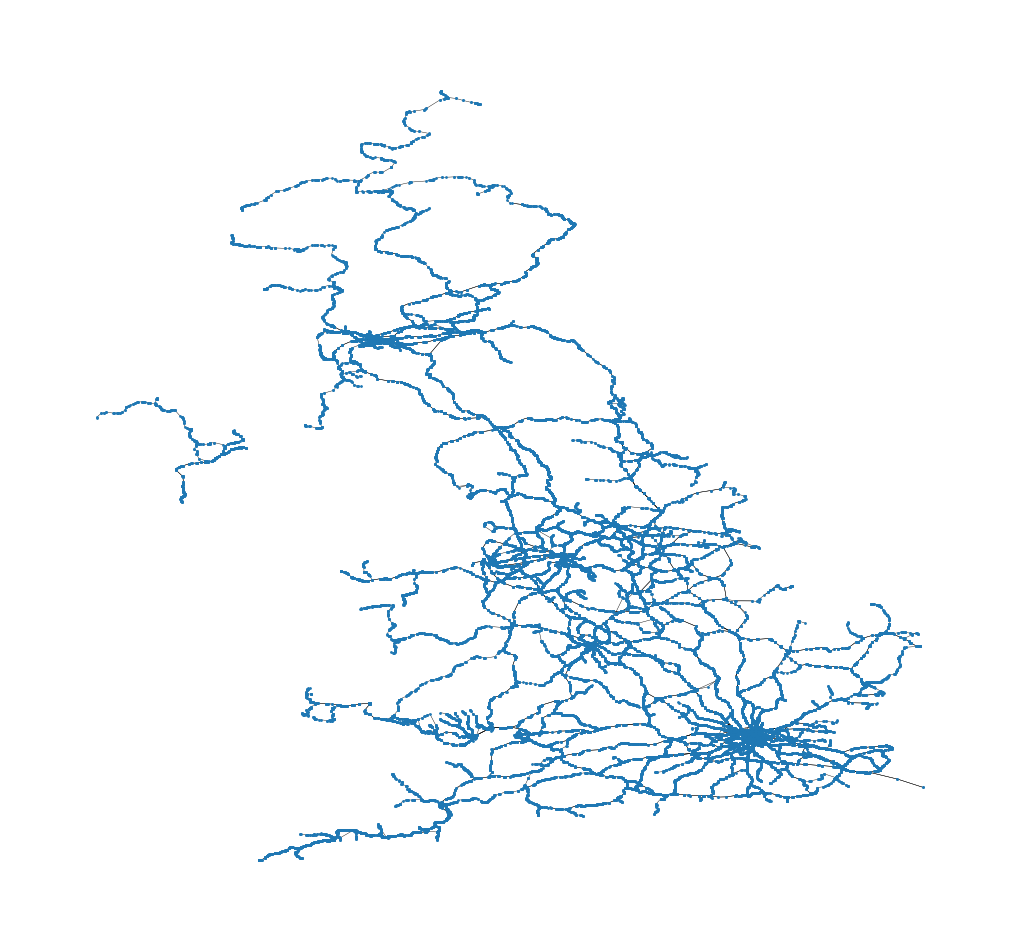

In [145]:
plt.figure(figsize=(10, 12))

pos = {n: (n[0], n[1]) for n in G_connected.nodes()}

nx.draw(
    G_connected,
    pos,
    node_size=1,
    width=0.3,
    edge_color="black"
)

plt.gca().set_aspect("equal")
plt.show()

## We want to remove Northern Ireland because it is not connected to the mainland network in real life

In [146]:
target = np.array([-5.93, 54.60]) #Longitude and latitude of Belfast (Capital of Northern Ireland)

#closest node in the graph
nodes = np.array([np.array(n) for n in G_connected.nodes()])
dists = np.linalg.norm(nodes - target, axis=1)
closest_node = tuple(nodes[dists.argmin()])

print("Closest node is :", closest_node)

#Find and remove the component associated to this point (so removing Northern Ireland)
component_NI = next(comp for comp in nx.connected_components(G_connected) if closest_node in comp)

print("NI component size :", len(component_NI))

G_final = G_connected.copy()
G_final.remove_nodes_from(component_NI)

Closest node is : (-5.9246143, 54.605539)
NI component size : 788


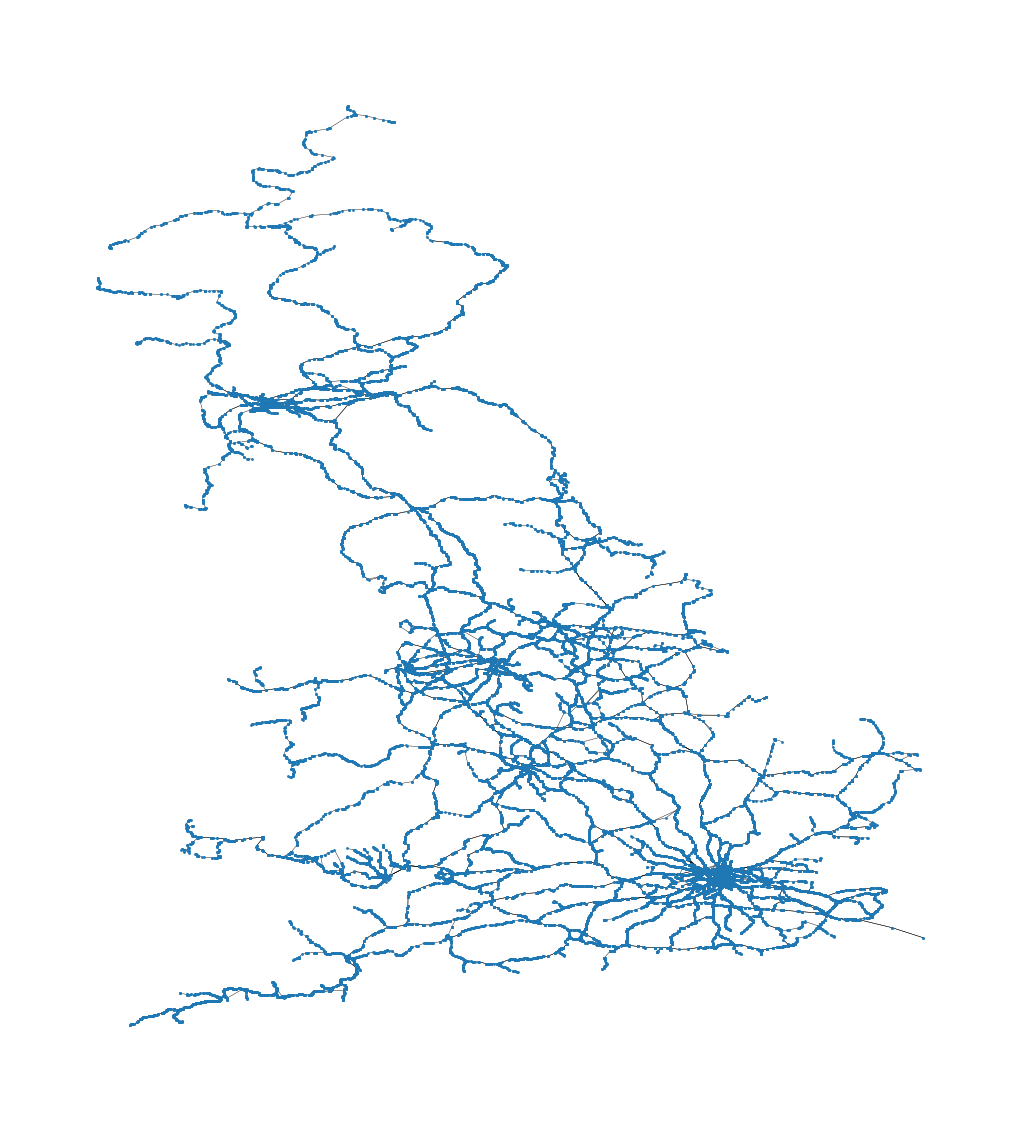

In [147]:
plt.figure(figsize=(10, 12))

pos = {n: (n[0], n[1]) for n in G_final.nodes()}
nx.draw(G_final, pos, node_size=1, width=0.3, edge_color="black")

plt.gca().set_aspect("equal")
plt.show()

In [148]:
m = folium.Map(
    location=[54, -2],
    zoom_start=6,
    tiles="CartoDB Positron"
)

#Add edges
for u, v, d in G_final.edges(data=True):
    if isinstance(u, tuple) and isinstance(v, tuple):
        folium.PolyLine(
            locations=[(u[1], u[0]), (v[1], v[0])],
            color="blue",
            weight=2,
            opacity=0.6
        ).add_to(m)

#Add nodes
for n, d in G_final.nodes(data=True):
    if not (isinstance(n, tuple) and len(n) == 2):
        continue

    lon ,lat = n

    folium.CircleMarker(
        location=[lat, lon],
        radius=1,
        color="red",
        fill=True,
        fill_opacity = 0.5
    ).add_to(m)

m.save("graph.html")
#m

### Is the network now fully connected ? Yes if there is only 1 component

In [149]:
nx.number_connected_components(G_final)

1

### Check the degrees of each node

In [150]:
degrees = [d for _, d in G_final.degree()]
print("min:", np.min(degrees))
print("max:", np.max(degrees))
print("mean:", np.mean(degrees))
print("degree=1:", degrees.count(1))
print("degree=2:", degrees.count(2))
print("degree>=3:", sum(d>=3 for d in degrees))

min: 1
max: 6
mean: 2.0546006983810257
degree=1: 2727
degree=2: 57214
degree>=3: 6212


## Add attributes

In [151]:
stations_in_G = [n for n, d in G.nodes(data=True) if d.get("type") == "station"]
len(stations_in_G)

11696

In [152]:
nodes_final = list(G_final.nodes())
coords_final = []
for n in nodes_final:
    lat = G_final.nodes[n].get('lat')
    lon = G_final.nodes[n].get('lon')
    coords_final.append([float(lat), float(lon)] if lat is not None and lon is not None else [0.0, 0.0])

tree = KDTree(coords_final)

matched_nodes = 0
skipped_invalid_coords = 0

for n in stations_in_G:
    st_code = stanox_map.get(n)
    lat_g = G.nodes[n].get('lat')
    lon_g = G.nodes[n].get('lon')
    
    if st_code is not None and lat_g is not None and lon_g is not None:
        try:
            f_lat = float(lat_g)
            f_lon = float(lon_g)
            
            if not np.isfinite(f_lat) or not np.isfinite(f_lon):
                skipped_invalid_coords += 1
                continue
                
            distance, index = tree.query([f_lat, f_lon])
            
            if distance < 0.005:
                node_proche = nodes_final[index]
                G_final.nodes[node_proche]['stanox'] = str(st_code).strip().zfill(5)
                matched_nodes += 1
                
        except (ValueError, TypeError):
            skipped_invalid_coords += 1
            continue

In [153]:
[(n, d) for n, d in G_final.nodes(data=True) if isinstance(n, tuple)][:2]

[((1.1454283, 51.2592228),
  {'type': 'osm_point', 'lon': 1.1454283, 'lat': 51.2592228}),
 ((-2.5807156, 51.4484134),
  {'type': 'osm_point', 'lon': -2.5807156, 'lat': 51.4484134})]

In [154]:
for u, v, d in G.edges(data=True):
    if u in G_final and v in G_final:
        if not G_final.has_edge(u, v):
            G_final.add_edge(u, v, **d)
        else:
            G_final[u][v].update(d)

In [155]:
list(G_final.edges(data=True))[:2]

[((1.1454283, 51.2592228),
  (1.1400766, 51.2606539),
  {'distance': 0.25163964288055435,
   'maxspeed': 90.0,
   'loading_gauge': 7.0,
   'electrified': '3rd_Rail',
   'gauge': '1435',
   'tracks': 2,
   'usage': 'main',
   'elr': 'FDM'}),
 ((1.1454283, 51.2592228),
  (1.1456842, 51.2591524),
  {'distance': 0.012086838315614417,
   'maxspeed': 90.0,
   'loading_gauge': 7.0,
   'electrified': '3rd_Rail',
   'gauge': '1435',
   'tracks': 2,
   'usage': 'main',
   'elr': 'FDM'})]

In [156]:
G_final.number_of_nodes(), G_final.number_of_edges()

(66153, 67959)

## Save graph

In [157]:
#Optionnal
with open("graph.gpickle", "wb") as f:
    pickle.dump(G_final, f)

## Load graph

In [158]:
#Optionnal
with open("graph.gpickle", "rb") as f:
    G_final = pickle.load(f)

## Select an area for a first case study : Greater London

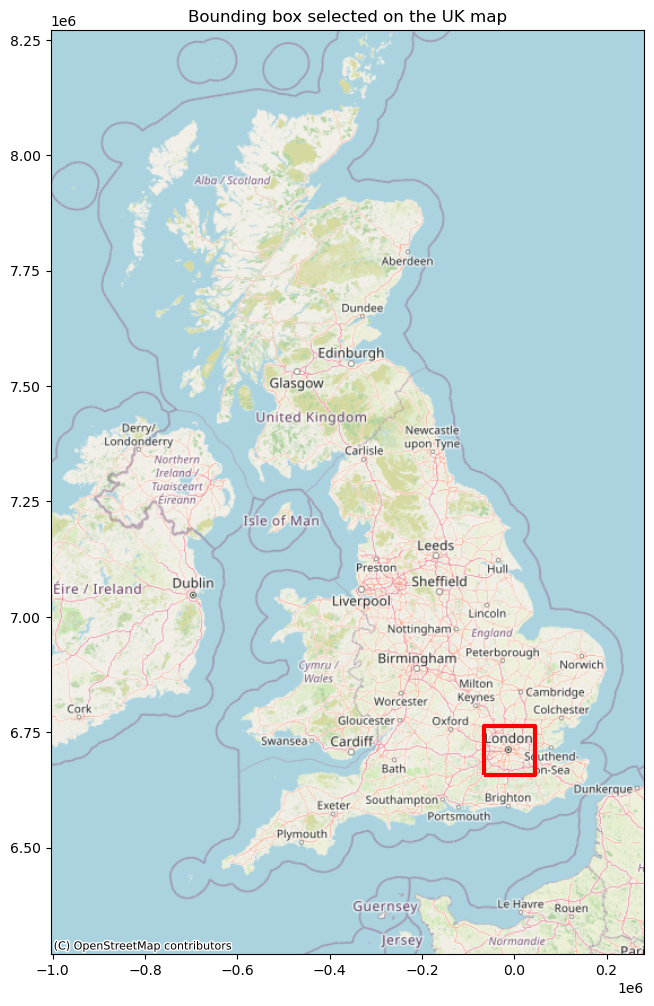

In [159]:
#Bounding box to test (can be modified)
minx, miny = -0.6, 51.2
maxx, maxy = 0.4, 51.8

bbox_poly = box(minx, miny, maxx, maxy)
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_poly], crs="EPSG:4326")

uk_minx, uk_miny = -8.5, 49.5
uk_maxx, uk_maxy = 2.0, 59.0

uk_poly = box(uk_minx, uk_miny, uk_maxx, uk_maxy)
uk_gdf = gpd.GeoDataFrame(geometry=[uk_poly], crs="EPSG:4326")

uk_web = uk_gdf.to_crs(3857)
bbox_web = bbox_gdf.to_crs(3857)

fig, ax = plt.subplots(figsize=(10, 12))

uk_web.boundary.plot(ax=ax, linewidth=0)

bbox_web.boundary.plot(ax=ax, color="red", linewidth=3)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("Bounding box selected on the UK map")
plt.show()

## Subgraph

In [160]:
lat_min, lat_max = 51.2, 51.8
lon_min, lon_max = -0.6, 0.4

nodes_to_keep = []

for n, d in G.nodes(data=True):

    lat = d.get("lat")
    lon = d.get("lon")

    if lat is not None and lon is not None:

        if lat_min <= lat <= lat_max and lon_min <= lon <= lon_max:
            nodes_to_keep.append(n)

G_london = G.subgraph(nodes_to_keep).copy()

In [161]:
largest_cc = max(nx.connected_components(G_london), key=len)

G_london = G_london.subgraph(largest_cc).copy()

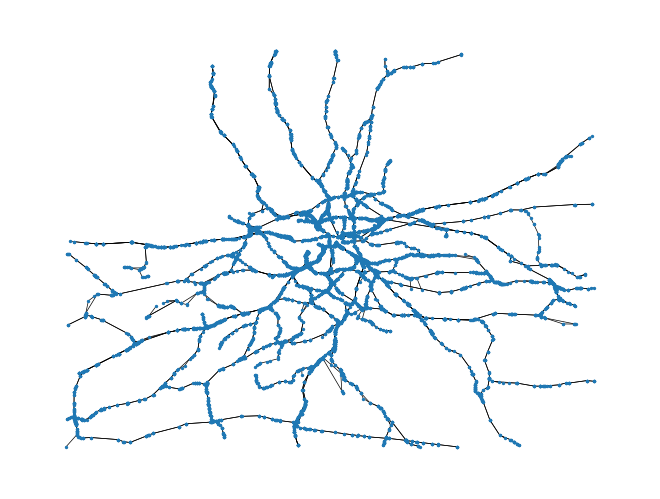

In [162]:
pos = {
    n: (d["lon"], d["lat"])
    for n, d in G_london.nodes(data=True)
    if "lon" in d and "lat" in d
}

nx.draw(
    G_london,
    pos,
    node_size=2,
    width=0.5,
    with_labels=False
)

In [163]:
print("Nodes :", G_london.number_of_nodes())
print("Edges :", G_london.number_of_edges())

Nodes : 10095
Edges : 10454


In [164]:
print(nx.number_connected_components(G_london))

1


In [165]:
degrees = [d for n, d in G_london.degree()]

avg_degree = sum(degrees) / len(degrees)

print(avg_degree)

2.071124318969787


In [166]:
list(G_final.nodes(data=True))[:2]

[((1.1454283, 51.2592228),
  {'type': 'osm_point', 'lon': 1.1454283, 'lat': 51.2592228}),
 ((-2.5807156, 51.4484134),
  {'type': 'osm_point', 'lon': -2.5807156, 'lat': 51.4484134})]

In [167]:
list(G_london.edges(data=True))[:2]

[((-0.0988616, 51.4973916),
  (-0.0985157, 51.4951534),
  {'distance': 0.15536053947488085,
   'maxspeed': 60.0,
   'loading_gauge': 7.0,
   'electrified': '3rd_Rail',
   'gauge': '1435',
   'tracks': 2,
   'usage': 'main',
   'elr': 'HHH'}),
 ((-0.0988616, 51.4973916),
  (-0.099215, 51.4980146),
  {'distance': 0.04565088254080461,
   'maxspeed': 60.0,
   'loading_gauge': 7.0,
   'electrified': '3rd_Rail',
   'gauge': '1435',
   'tracks': 4,
   'usage': 'main',
   'elr': nan})]

# Add name and tiploc

In [168]:
valid_nodes = []
valid_coords = []

for n in G_london.nodes:
    if n in G.nodes:
        d = G.nodes[n]
        lon = d.get("lon")
        lat = d.get("lat")

        if lon is not None and lat is not None and math.isfinite(lon) and math.isfinite(lat):
            valid_nodes.append(n)
            valid_coords.append([lon, lat])

valid_coords = np.array(valid_coords)
tree = cKDTree(valid_coords)

for _, row in df_name_loc.iterrows():
    lon = row["long"]
    lat = row["lat"]

    if lon is None or lat is None:
        continue
    if not (math.isfinite(lon) and math.isfinite(lat)):
        continue

    tiploc = row["tiploc"]
    name = row["name"]

    dist, idx = tree.query([lon, lat])
    nearest_node = valid_nodes[idx]

    G_london.nodes[nearest_node]["tiploc"] = tiploc
    G_london.nodes[nearest_node]["name"] = name

In [169]:
count_tiploc = sum(
    1 for n, d in G_london.nodes(data=True)
    if "tiploc" in d
)

count_name = sum(
    1 for n, d in G_london.nodes(data=True)
    if "name" in d
)

print("Nœuds avec tiploc :", count_tiploc)
print("Nœuds avec name   :", count_name)
print("Total nœuds       :", G_london.number_of_nodes())

Nœuds avec tiploc : 460
Nœuds avec name   : 463
Total nœuds       : 10095


## Add stanox

In [170]:
df_STAN_TIP.columns

Index(['id', 'NLC', 'STANOX', 'TIPLOC', '3ALPHA', 'UIC', 'NLCDESC',
       'NLCDESC16'],
      dtype='object')

In [171]:
tiploc_to_stanox = {
    row["TIPLOC"]: row["STANOX"]
    for _, row in df_STAN_TIP.iterrows()
    if isinstance(row["TIPLOC"], str)
}

count_added = 0

for n, d in G_london.nodes(data=True):
    tiploc = d.get("tiploc")
    if tiploc in tiploc_to_stanox:
        G_london.nodes[n]["stanox"] = tiploc_to_stanox[tiploc]
        count_added += 1

print("STANOX added :", count_added)

STANOX added : 457


In [172]:
count_stanox = sum(
    1 for _, d in G_london.nodes(data=True)
    if "stanox" in d
)

print("Nodes with stanox :", count_stanox)
print("Nodes with tiploc :", sum("tiploc" in d for _, d in G_london.nodes(data=True)))

Nodes with stanox : 462
Nodes with tiploc : 460


In [173]:
sample = [
    (n, {k: d[k] for k in ["lon", "lat", "tiploc", "name", "stanox"] if k in d})
    for n, d in G_london.nodes(data=True)
    if "tiploc" in d
][:10]

sample

[('RDLSDWN',
  {'lon': -0.099436,
   'lat': 51.332611,
   'tiploc': 'RDLSDWN',
   'name': 'Riddlesdown',
   'stanox': '87744'}),
 ('CMDNRD',
  {'lon': -0.139764,
   'lat': 51.541889,
   'tiploc': 'CMDNRD',
   'name': 'Camden Road',
   'stanox': '72421'}),
 ('ESHER',
  {'lon': -0.354714,
   'lat': 51.379642,
   'tiploc': 'ESHER',
   'name': 'Esher',
   'stanox': '86002'}),
 ('LDYW',
  {'lon': -0.019445,
   'lat': 51.456291,
   'tiploc': 'LDYW',
   'name': 'Ladywell',
   'stanox': '88309'}),
 ('BNSBDGE',
  {'lon': -0.252051,
   'lat': 51.471676,
   'tiploc': 'BNSBDGE',
   'name': 'Barnes Bridge',
   'stanox': '87150'}),
 ('SIDCUP',
  {'lon': 0.103342,
   'lat': 51.434361,
   'tiploc': 'SIDCUP',
   'name': 'Sidcup',
   'stanox': '88461'}),
 ((0.1197351, 51.5667313),
  {'lon': 0.1197351,
   'lat': 51.5667313,
   'tiploc': 'GODMAYS',
   'name': 'Goodmayes',
   'stanox': '50412'}),
 ('REDHILL',
  {'lon': -0.164851,
   'lat': 51.240124,
   'tiploc': 'REDHILL',
   'name': 'Redhill',
   'stanox

## Analysis of the subgraph (London)

In [174]:
print("Nodes:", G_london.number_of_nodes())
print("Edges:", G_london.number_of_edges())
print("Number of components:", nx.number_connected_components(G_london))

Nodes: 10095
Edges: 10454
Number of components: 1


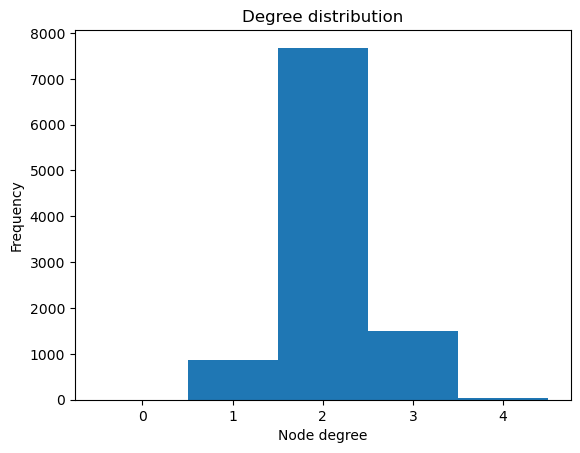

In [175]:
degrees = [d for n, d in G_london.degree()]

plt.hist(degrees, bins=range(max(degrees)+2), align='left')

plt.xlabel("Node degree")
plt.ylabel("Frequency")
plt.title("Degree distribution")

plt.show()

In [176]:
top_degree = sorted(
    G_london.degree(),
    key=lambda x: x[1],
    reverse=True
)[:20]

for node, degree in top_degree:
    attrs = G_london.nodes[node]

    if "name" in attrs:
        display_name = attrs["name"]
    elif "tiploc" in attrs:
        display_name = attrs["tiploc"]
    else:
        display_name = "Unknown"

    print(f"{display_name} ({node}) : {degree}")

Unknown ((-0.0863657, 51.3861687)) : 4
Unknown ((-0.1149192, 51.4995671)) : 4
Unknown ((-0.0873369, 51.5200807)) : 4
Unknown ((-0.0613572, 51.550288)) : 4
Unknown ((-0.0145929, 51.4659457)) : 4
Unknown ((-0.0596597, 51.5470377)) : 4
Unknown ((0.0042518, 51.446856)) : 4
Unknown ((-0.1150438, 51.4971623)) : 4
Unknown ((0.0251778, 51.5098454)) : 4
Unknown ((-0.1149285, 51.4974397)) : 4
Unknown ((-0.4192922, 51.2918841)) : 4
Unknown ((-0.0054259, 51.5408142)) : 4
Unknown ((-0.1149876, 51.4971341)) : 4
Unknown ((-0.5619278, 51.4028783)) : 4
Unknown ((-0.1151909, 51.4969294)) : 4
Unknown ((-0.2554898, 51.5218732)) : 4
Unknown ((-0.1145392, 51.5005458)) : 4
Unknown ((-0.0807342, 51.5204417)) : 4
Unknown ((-0.243849, 51.5310575)) : 4
Unknown ((-0.1148597, 51.4995452)) : 4


In [177]:
station_nodes = [
    (node, degree)
    for node, degree in G_london.degree()
    if "name" in G_london.nodes[node]
]

top_degree = sorted(
    station_nodes,
    key=lambda x: x[1],
    reverse=True
)

for node, degree in top_degree:
    print(G_london.nodes[node]["name"], degree)

Hatch End 3
Upminster 3
Gerrards Cross 3
West Ruislip 3
Staines 3
Barnes 3
South Acton 3
Southall 3
Twickenham 3
Wembley Stadium 3
South Ruislip 3
Harringay 3
Radlett 3
Battersea Park 3
Slade Green 3
Goodmayes 2
West Drayton 2
Iver 2
London Marylebone 2
Emerson Park 2
Watford North 2
Oxted 2
South Hampstead 2
Wokingham 2
Kensal Rise 2
Harlow Mill 2
Tolworth 2
Hever 2
Bricket Wood 2
Broxbourne 2
Upper Holloway 2
Watford Junction 2
Streatham Hill 2
Hanwell 2
Enfield Town 2
Park Street 2
Dorking 2
Greenford 2
Rickmansworth 2
Sydenham 2
Angmering 2
London Euston 2
Northolt Park 2
Brookwood 2
Chadwell Heath 2
Hornsey 2
Surbiton 2
Earlswood (Surrey) 2
West Horndon 2
Hemel Hempstead 2
Grove Park 2
Alexandra Palace 2
Sundridge Park 2
Norwood Junction 2
How Wood 2
Woking 2
Chilworth 2
Harlesden 2
Brimsdown 2
Leigh (Kent) 2
St Helier 2
Clapham Junction 2
New Southgate 2
Chertsey 2
Bellingham 2
Dorking West 2
Stonebridge Park 2
Stratford International 2
Pulborough 2
Whitby 2
Acton Main Line 2
Den

## Spread of gauges

In [178]:
gauges = []

for u, v, d in G_london.edges(data=True):
    gauges.append(d.get("loading_gauge"))

gauges_counts = pd.Series(gauges).value_counts(dropna=False)
print(gauges_counts)

7.0     5905
10.0    3576
6.0      487
NaN      343
8.0      132
9.0       11
Name: count, dtype: int64


## Spread of electrification

In [179]:
electrification = []

for u, v, d in G_london.edges(data=True):
    electrification.append(d.get("electrified"))

elec_counts = pd.Series(electrification).value_counts(dropna=False)
print(elec_counts)

3rd_Rail    5895
Overhead    3864
No           352
None         343
Name: count, dtype: int64


## Add STANOX to all graphs

In [180]:
stations_ref = []
for node, data in G.nodes(data=True):
    stanox = data.get('stanox')
    if stanox is not None and str(stanox).strip() != '':
        try:
            if isinstance(node, (tuple, list)) and len(node) >= 2 and isinstance(node[0], (int, float)):
                lon, lat = float(node[0]), float(node[1])
            elif 'lon' in data and 'lat' in data:
                lon, lat = float(data['lon']), float(data['lat'])
            else:
                continue
                
            if np.isfinite(lon) and np.isfinite(lat):
                stations_ref.append({
                    'lon': lon, 
                    'lat': lat, 
                    'stanox': str(stanox).zfill(5)
                })
        except (ValueError, TypeError):
            continue

london_tagged = tag_graph_with_kdtree(G_london, stations_ref)
print(f"{london_tagged} nodes tagged in G_london")

final_tagged = tag_graph_with_kdtree(G_final, stations_ref)
print(f"{final_tagged} nodes tagged in G_final")

374 nodes tagged in G_london
1508 nodes tagged in G_final


## Save subgraph

In [181]:
#Optionnal
with open("subgraph.gpickle", "wb") as f:
    pickle.dump(G_london, f)

## Load subgraph

In [182]:
#Optionnal
with open("subgraph.gpickle", "rb") as f:
    G_london = pickle.load(f)

# Network resilience

### Analysis of 1 train trip

In [183]:
df_movement_first = pd.read_csv(movement1)

In [184]:
df_movement_first.head()

,id,created_unix,msg_type,source_dev_id,user_id,original_data_source,msg_queue_timestamp,source_system_id,event_type,gbtt_timestamp,...,train_service_code,toc_id,loc_stanox,auto_expected,direction_ind,route,planned_event_type,next_report_stanox,line_ind,Datetime
0,652732363,1777628679,3,NaN,NaN,SMART,1777628678000,TRUST,DEPARTURE,NaN,...,54606070,9,51123,True,UP,1.0,DEPARTURE,51122.0,NaN,2026-05-01 10:44:00.000
1,652737063,1777629084,3,FQ42159,NaN,TOPS,1777629084000,TRUST,DEPARTURE,1.777632e+12,...,54606070,9,51127,False,NaN,NaN,DEPARTURE,51129.0,NaN,2026-05-01 10:37:00.000
2,652743586,1777629641,3,NaN,NaN,SMART,1777629640000,TRUST,DEPARTURE,NaN,...,54606070,9,51121,True,UP,1.0,DEPARTURE,51203.0,U,2026-05-01 11:00:00.000
3,652750813,1777630264,3,NaN,NaN,SMART,1777630263000,TRUST,ARRIVAL,NaN,...,54606070,9,51203,True,NaN,0.0,ARRIVAL,51311.0,NaN,2026-05-01 11:11:00.000
4,652751402,1777630312,3,NaN,NaN,SMART,1777630310000,TRUST,DEPARTURE,NaN,...,54606070,9,51203,True,UP,1.0,DEPARTURE,51311.0,U,2026-05-01 11:11:00.000


In [185]:
df_movement_first.columns

Index(['id', 'created_unix', 'msg_type', 'source_dev_id', 'user_id',
       'original_data_source', 'msg_queue_timestamp', 'source_system_id',
       'event_type', 'gbtt_timestamp', 'original_loc_stanox',
       'planned_timestamp', 'timetable_variation', 'original_loc_timestamp',
       'current_train_id', 'delay_monitoring_point', 'next_report_run_time',
       'reporting_stanox', 'actual_timestamp', 'correction_ind',
       'event_source', 'train_file_address', 'platform', 'division_code',
       'train_terminated', 'train_id', 'offroute_ind', 'variation_status',
       'train_service_code', 'toc_id', 'loc_stanox', 'auto_expected',
       'direction_ind', 'route', 'planned_event_type', 'next_report_stanox',
       'line_ind', 'Datetime'],
      dtype='object')

## Litle bit of cleaning

In [186]:
df_movement_first['Datetime'] = pd.to_datetime(df_movement_first['Datetime'])
df_movement_first['loc_stanox'] = df_movement_first['loc_stanox'].astype(str).str.strip().str.zfill(5)

df_train_clean = df_movement_first.dropna(subset=['loc_stanox', 'timetable_variation']).copy()
df_train_clean['loc_stanox'] = df_train_clean['loc_stanox'].astype(str).str.replace('.0', '', regex=False)
df_train_clean = df_train_clean.sort_values(by='Datetime')
df_parcours_train = df_train_clean[['Datetime', 'actual_timestamp', 'loc_stanox', 'next_report_stanox','timetable_variation', 'variation_status', 'event_type', 'planned_event_type', 'direction_ind', 'train_terminated', 'train_id']].copy()

In [187]:
df_parcours_final = df_parcours_train.sort_values(by='Datetime')
df_parcours_final['timetable_variation'] = np.where(df_parcours_final['variation_status'] == 'EARLY', df_parcours_final['timetable_variation'] * (-1), df_parcours_final['timetable_variation'])
df_parcours_final.head()

,Datetime,actual_timestamp,loc_stanox,next_report_stanox,timetable_variation,variation_status,event_type,planned_event_type,direction_ind,train_terminated,train_id
1,2026-05-01 10:37:00,1777631820000,51127,51129.0,-11,EARLY,DEPARTURE,DEPARTURE,NaN,False,514E24CH01
0,2026-05-01 10:44:00,1777632240000,51123,51122.0,-11,EARLY,DEPARTURE,DEPARTURE,UP,False,514E24CH01
2,2026-05-01 11:00:00,1777633200000,51121,51203.0,-1,EARLY,DEPARTURE,DEPARTURE,UP,False,514E24CH01
3,2026-05-01 11:11:00,1777633860000,51203,51311.0,0,ON TIME,ARRIVAL,ARRIVAL,NaN,False,514E24CH01
4,2026-05-01 11:11:00,1777633860000,51203,51311.0,0,ON TIME,DEPARTURE,DEPARTURE,UP,False,514E24CH01


In [188]:
print(df_parcours_final['variation_status'].value_counts())

variation_status
EARLY      274
LATE       139
ON TIME     85
Name: count, dtype: int64


## Add STANOX to all graphs

In [189]:
stations_ref = []
for node, data in G.nodes(data=True):
    stanox = data.get('stanox')
    if stanox is not None and str(stanox).strip() != '':
        try:
            if isinstance(node, (tuple, list)) and len(node) >= 2 and isinstance(node[0], (int, float)):
                lon, lat = float(node[0]), float(node[1])
            elif 'lon' in data and 'lat' in data:
                lon, lat = float(data['lon']), float(data['lat'])
            else:
                continue
                
            if np.isfinite(lon) and np.isfinite(lat):
                stations_ref.append({
                    'lon': lon, 
                    'lat': lat, 
                    'stanox': str(stanox).zfill(5)
                })
        except (ValueError, TypeError):
            continue

london_tagged = tag_graph_with_kdtree(G_london, stations_ref)
print(f"{london_tagged} nodes tagged in G_london")

final_tagged = tag_graph_with_kdtree(G_final, stations_ref)
print(f"{final_tagged} nodes tagged in G_final")

374 nodes tagged in G_london
1508 nodes tagged in G_final


# Train movement data

## Analysis of a 10 days dataset

In [190]:
df_movement_month = pd.read_csv(movement_month)
df_movement_month.head()

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_27348\870184373.py:1: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  df_movement_month = pd.read_csv(movement_month)


,id,created_unix,msg_type,source_dev_id,user_id,original_data_source,msg_queue_timestamp,source_system_id,event_type,gbtt_timestamp,...,variation_status,train_service_code,toc_id,loc_stanox,auto_expected,direction_ind,route,planned_event_type,next_report_stanox,line_ind
0,631122478,1775050271,3,NaN,NaN,SMART,1775050270000,TRUST,DEPARTURE,NaN,...,EARLY,56461880,54,32519,True,DOWN,2.0,DEPARTURE,32117.0,NaN
1,631122519,1775050274,3,VDAK,#QRPETBE,SDR,1775050272000,TRUST,DEPARTURE,NaN,...,EARLY,52660490,97,11209,NaN,NaN,NaN,DEPARTURE,11210.0,NaN
2,631122520,1775050274,3,NaN,NaN,SMART,1775050273000,TRUST,DEPARTURE,NaN,...,EARLY,53790121,5,7961,True,DOWN,3.0,DEPARTURE,4120.0,NaN
3,631122557,1775050277,3,NaN,NaN,SMART,1775050276000,TRUST,DEPARTURE,NaN,...,EARLY,52663390,97,56625,True,UP,1.0,DEPARTURE,56598.0,C
4,631122573,1775050277,3,NaN,NaN,SMART,1775050277000,TRUST,DEPARTURE,NaN,...,LATE,54606070,9,86061,True,UP,2.0,DEPARTURE,74265.0,NaN


In [191]:
df_movement_month['Datetime'] = pd.to_datetime(df_movement_month['actual_timestamp'],unit='ms')
df_movement_month['loc_stanox'] = df_movement_month['loc_stanox'].astype(str).str.strip().str.zfill(5)

df_month_clean = df_movement_month.dropna(subset=['loc_stanox', 'timetable_variation']).copy()
df_month_clean['loc_stanox'] = df_month_clean['loc_stanox'].astype(str).str.replace('.0', '', regex=False)
df_month_clean = df_month_clean.sort_values(by='Datetime')
df_trip_month = df_month_clean[['Datetime', 'actual_timestamp', 'loc_stanox', 'next_report_stanox','timetable_variation', 'variation_status', 'event_type', 'planned_event_type', 'direction_ind', 'train_terminated', 'train_id']].copy()

In [192]:
df_month_final = df_trip_month.sort_values(by='Datetime')
df_month_final['timetable_variation'] = np.where(df_month_final['variation_status'] == 'EARLY', df_month_final['timetable_variation'] * (-1), df_month_final['timetable_variation'])
df_month_final.head()

,Datetime,actual_timestamp,loc_stanox,next_report_stanox,timetable_variation,variation_status,event_type,planned_event_type,direction_ind,train_terminated,train_id
5436,2026-03-31 23:00:00,1774998000000,63201,NaN,-5,EARLY,ARRIVAL,DESTINATION,NaN,True,566Y751R31
3344,2026-03-31 23:00:00,1774998000000,57403,57404.0,-5,EARLY,ARRIVAL,ARRIVAL,NaN,False,156V02CY31
9961,2026-03-31 23:00:00,1774998000000,44517,NaN,0,ON TIME,ARRIVAL,DESTINATION,NaN,True,556J161831
3345,2026-03-31 23:00:00,1774998000000,53221,53414.0,-1,EARLY,ARRIVAL,ARRIVAL,NaN,False,886L34CY31
3346,2026-03-31 23:00:00,1774998000000,79798,78608.0,4,LATE,ARRIVAL,ARRIVAL,NaN,False,796M11C931


In [193]:
date_debut = df_month_final["Datetime"].min()
date_fin = df_month_final["Datetime"].max()

print("Beginning :", date_debut)
print("End :", date_fin)
print("Total duration :", date_fin - date_debut)

Beginning : 2026-03-31 23:00:00
End : 2026-04-10 23:00:00
Total duration : 10 days 00:00:00


### Compute and inject flow in the graphs

In [194]:
london_stanox_to_node = {}
for node, data in G_london.nodes(data=True):
    if data.get('ox') is not None or data.get('stanox') is not None:
        st_val = data.get('stanox') or data.get('ox')
        london_stanox_to_node[str(st_val).zfill(5)] = node


for u, v in G_london.edges():
    G_london[u][v]['traffic_flow'] = 0

df_sorted = df_month_final.sort_values(by=['train_id', 'actual_timestamp'])

#Traffic flow computation
matched_edges_count = 0
routing_failures = 0

for train_id, group in df_sorted.groupby('train_id'):
    train_stanox_list = []
    for st in group['loc_stanox'].dropna():
        try:
            train_stanox_list.append(str(int(float(st))).zfill(5))
        except (ValueError, TypeError):
            continue
            
    path_nodes = [london_stanox_to_node[st] for st in train_stanox_list if st in london_stanox_to_node]
    
    clean_path = []
    for node in path_nodes:
        if not clean_path or node != clean_path[-1]:
            clean_path.append(node)
            
    if len(clean_path) > 1:
        for i in range(len(clean_path) - 1):
            source = clean_path[i]
            target = clean_path[i+1]
            
            try:
                actual_track_path = nx.shortest_path(G_london, source=source, target=target)
                
                for j in range(len(actual_track_path) - 1):
                    u = actual_track_path[j]
                    v = actual_track_path[j+1]
                    
                    if G_london.has_edge(u, v):
                        G_london[u][v]['traffic_flow'] += 1
                        matched_edges_count += 1
                    elif G_london.has_edge(v, u):
                        G_london[v][u]['traffic_flow'] += 1
                        matched_edges_count += 1
                        
            except (nx.NetworkXNoPath, nx.NodeNotFound):
                routing_failures += 1

## Flow heatmap of London

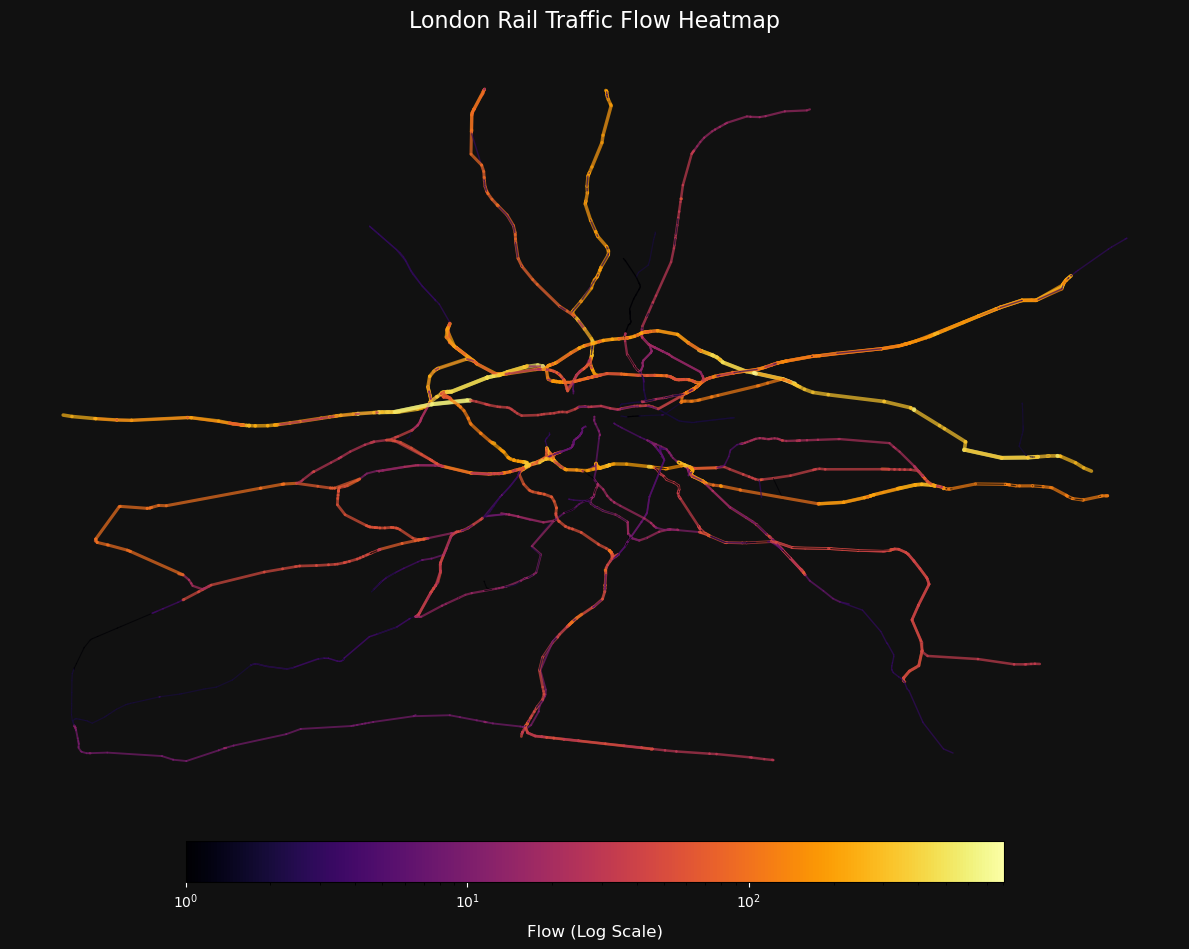

In [195]:
lines = []
flows = []

for u, v, data in G_london.edges(data=True):
    flow = data.get('traffic_flow', 0)
    if flow > 0:
        if isinstance(u, (tuple, list)):
            u_lon, u_lat = u[0], u[1]
        else:
            u_lon, u_lat = G_london.nodes[u]['lon'], G_london.nodes[u]['lat']
            
        if isinstance(v, (tuple, list)):
            v_lon, v_lat = v[0], v[1]
        else:
            v_lon, v_lat = G_london.nodes[v]['lon'], G_london.nodes[v]['lat']
            
        lines.append(([u_lon, v_lon], [u_lat, v_lat]))
        flows.append(flow)

plt.figure(figsize=(12, 10), facecolor='#111111')
ax = plt.subplot(111, facecolor='#111111')

flows = np.array(flows)
norm = mcolors.LogNorm(vmin=1, vmax=flows.max())
cmap = cm.inferno


for (lons, lats), flow in zip(lines, flows):
    linewidth = 0.5 + 2.5 * (np.log1p(flow) / np.log1p(flows.max()))
    
    ax.plot(lons, lats, 
            color=cmap(norm(flow)), 
            linewidth=linewidth, 
            alpha=0.7, 
            solid_capstyle='round')


ax.set_title("London Rail Traffic Flow Heatmap", color='white', fontsize=16, pad=20)
ax.axis('off')

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cb = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7)
cb.set_label('Flow (Log Scale)', color='white', fontsize=12, labelpad=10)
cb.ax.xaxis.set_tick_params(color='white')
plt.setp(cb.ax.get_xticklabels(), color='white')

plt.tight_layout()
plt.show()

## Flow heatmap of the UK

In [196]:
# final_stanox_to_node = {}
# for node, data in G_final.nodes(data=True):
#     if data.get('ox') is not None or data.get('stanox') is not None:
#         st_val = data.get('stanox') or data.get('ox')
#         final_stanox_to_node[str(st_val).zfill(5)] = node

# for u, v in G_final.edges():
#     G_final[u][v]['traffic_flow'] = 0

# df_sorted = df_month_final.sort_values(by=['train_id', 'actual_timestamp'])

# matched_edges_count = 0
# routing_failures = 0

# for train_id, group in df_sorted.groupby('train_id'):
#     train_stanox_list = []
#     for st in group['loc_stanox'].dropna():
#         try:
#             train_stanox_list.append(str(int(float(st))).zfill(5))
#         except (ValueError, TypeError):
#             continue
            
#     path_nodes = [final_stanox_to_node[st] for st in train_stanox_list if st in final_stanox_to_node]
    
#     clean_path = []
#     for node in path_nodes:
#         if not clean_path or node != clean_path[-1]:
#             clean_path.append(node)
            
#     if len(clean_path) > 1:
#         for i in range(len(clean_path) - 1):
#             source = clean_path[i]
#             target = clean_path[i+1]
            
#             try:
#                 actual_track_path = nx.shortest_path(G_final, source=source, target=target)
                
#                 for j in range(len(actual_track_path) - 1):
#                     u = actual_track_path[j]
#                     v = actual_track_path[j+1]
                    
#                     if G_final.has_edge(u, v):
#                         G_final[u][v]['traffic_flow'] += 1
#                         matched_edges_count += 1
#                     elif G_final.has_edge(v, u):
#                         G_final[v][u]['traffic_flow'] += 1
#                         matched_edges_count += 1
                        
#             except (nx.NetworkXNoPath, nx.NodeNotFound):
#                 routing_failures += 1

In [197]:
edge_traffic = [
    (u, v, data['traffic_flow']) 
    for u, v, data in G_final.edges(data=True) 
    if data.get('traffic_flow', 0) > 0
]

edge_traffic_sorted = sorted(edge_traffic, key=lambda x: x[2], reverse=True)

print("Top 5 high-flow segments in the UK")
for u, v, flow in edge_traffic_sorted[:5]:
    u_name = G_final.nodes[u].get('name', u)
    v_name = G_final.nodes[v].get('name', v)
    print(f"Edge from {u_name} to {v_name} || Total Traffic: {flow}")

Top 5 high-flow segments in the UK


In [198]:
G_work = G_final.copy()

final_stanox_to_nodes = {}
for node, data in G_work.nodes(data=True):
    st_val = data.get('stanox')
    if st_val is not None:
        st_str = str(st_val).strip().zfill(5)
        if st_str not in final_stanox_to_nodes:
            final_stanox_to_nodes[st_str] = []
        final_stanox_to_nodes[st_str].append(node)

for u, v in G_work.edges():
    G_work[u][v]['traffic_flow'] = 0

df_sorted = df_month_final.sort_values(by=['train_id', 'actual_timestamp'])
matched_edges_count = 0
routing_failures = 0

for train_id, group in df_sorted.groupby('train_id'):
    train_stanox_list = []
    for st in group['loc_stanox'].dropna():
        try:
            train_stanox_list.append(str(int(float(st))).zfill(5))
        except (ValueError, TypeError):
            continue
    
    clean_stanox = [st for st in train_stanox_list if st in final_stanox_to_nodes]
    
    clean_path_stanox = []
    for st in clean_stanox:
        if not clean_path_stanox or st != clean_path_stanox[-1]:
            clean_path_stanox.append(st)
            
    if len(clean_path_stanox) > 1:
        for i in range(len(clean_path_stanox) - 1):
            sources = final_stanox_to_nodes[clean_path_stanox[i]]
            targets = final_stanox_to_nodes[clean_path_stanox[i+1]]
            
            success = False
            for src in sources:
                for tgt in targets:
                    try:
                        actual_track_path = nx.shortest_path(G_work, source=src, target=tgt)
                        for j in range(len(actual_track_path) - 1):
                            u, v = actual_track_path[j], actual_track_path[j+1]
                            if G_work.has_edge(u, v): G_work[u][v]['traffic_flow'] += 1
                            elif G_work.has_edge(v, u): G_work[v][u]['traffic_flow'] += 1
                            matched_edges_count += 1
                        success = True
                        break
                    except (nx.NetworkXNoPath, nx.NodeNotFound):
                        continue
                if success: break
            if not success: routing_failures += 1
print(f"Segments de voies mis à jour : {matched_edges_count}")

Segments de voies mis à jour : 2055947


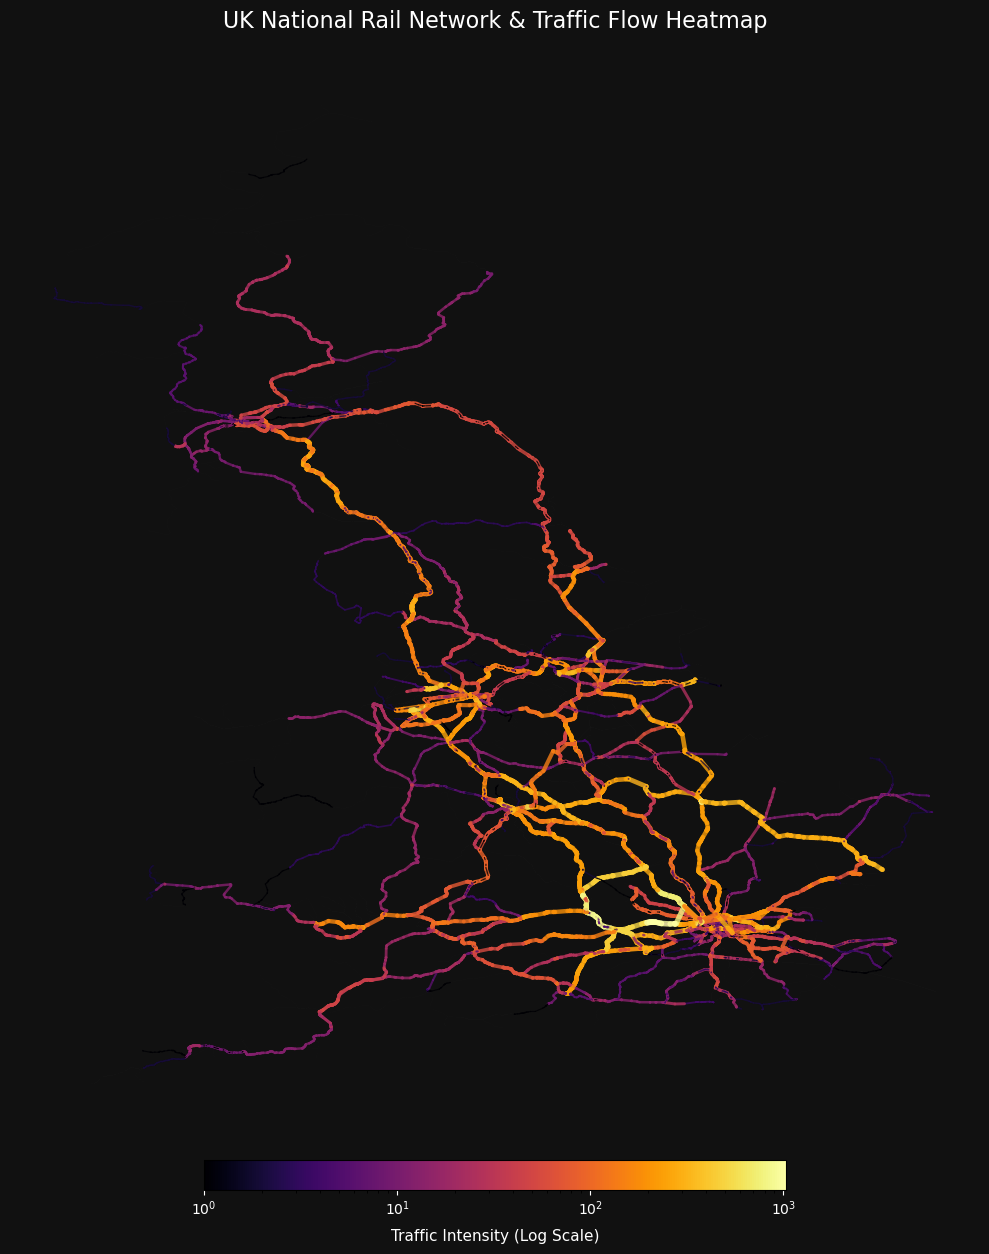

In [199]:
lines_traffic = []
flows = []
lines_background = []

for u, v, data in G_work.edges(data=True):
    if isinstance(u, (tuple, list)):
        u_lon, u_lat = u[0], u[1]
    else:
        u_lon, u_lat = G_work.nodes[u].get('lon'), G_work.nodes[u].get('lat')
        
    if isinstance(v, (tuple, list)):
        v_lon, v_lat = v[0], v[1]
    else:
        v_lon, v_lat = G_work.nodes[v].get('lon'), G_work.nodes[v].get('lat')
        
    if u_lon is None or u_lat is None or v_lon is None or v_lat is None:
        continue

    lines_background.append(([u_lon, v_lon], [u_lat, v_lat]))

    flow = data.get('traffic_flow', 0)
    if flow > 0:
        lines_traffic.append(([u_lon, v_lon], [u_lat, v_lat]))
        flows.append(flow)

plt.figure(figsize=(10, 14), facecolor='#111111')
ax = plt.subplot(111, facecolor='#111111')

for lons, lats in lines_background:
    ax.plot(lons, lats, color='#222222', linewidth=0.2, alpha=0.3)

flows = np.array(flows)
if len(flows) == 0:
    print("No traffic to display")
else:
    norm = mcolors.LogNorm(vmin=1, vmax=flows.max())
    cmap = cm.inferno

    for (lons, lats), flow in zip(lines_traffic, flows):
        linewidth = 0.5 + 3.5 * (np.log1p(flow) / np.log1p(flows.max()))
        ax.plot(lons, lats, 
                color=cmap(norm(flow)), 
                linewidth=linewidth, 
                alpha=0.8, 
                solid_capstyle='round')

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02, shrink=0.6)
    cb.set_label('Traffic Intensity (Log Scale)', color='white', fontsize=11, labelpad=8)
    cb.ax.xaxis.set_tick_params(color='white')
    plt.setp(cb.ax.get_xticklabels(), color='white')

ax.set_title("UK National Rail Network & Traffic Flow Heatmap", color='white', fontsize=16, pad=20)
ax.axis('off')

ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

# Bridge strikes

In [200]:
df_strikes = pd.read_csv(bridge_strikes)
df_strikes.head()

,Start Date of Incident,Network Region,Network Rail Route,ELR,Railway ID,ELR/ Structure Number,Asset Description,Asset Type,Start Mileage,Latitude,Longitude
0,00/01/1900,Eastern,ANG,EMP,1816,EMP/1816,STONEA ROAD (B1098),Underline Bridge,82.0066,52.518212,0.149384
1,00/01/1900,Eastern,ANG,MAH,1043,MAH/1043,"MANNINGTREE ROAD, MISTLEY",Underline Bridge,59.1474,51.947362,1.053891
2,00/01/1900,NW&C,CEN,CNN,39,CNN/39,COVENTRY OR SPON END VIADUCT,Viaduct,0.1022,NaN,NaN
3,00/01/1900,NW&C,CEN,MJI2,7,MJI2/7,CHERRY TREE HILL,Underline Bridge,161.1100,52.642012,-2.489306
4,02/01/2020,NW&C,CEN,ALC2,35,ALC2/35,BIRMINGHAM ROAD A5127,Underline Bridge,12.0352,52.659990,-1.834098


In [201]:
print(len(df_strikes))

df_strikes = df_strikes.dropna(subset=['Latitude', 'Longitude'])

print(f"Size after cleaning : {len(df_strikes)}")

6749
Size after cleaning : 4988


In [202]:
df_strikes.columns = df_strikes.columns.str.strip()

for col in df_strikes[['Start Date of Incident', 'ELR']]:
    print("\n Date with the most incidents :")
    counts = df_strikes[col].value_counts(dropna=False).head(5)
    for val, cnt in counts.items():
        print(f"- {str(val)[:45]:<45} : {cnt:<6} ({cnt/len(df_strikes)*100:.2f}%)")


 Date with the most incidents :
- 10/09/2020                                    : 13     (0.26%)
- 15/10/2021                                    : 12     (0.24%)
- 06/06/2022                                    : 12     (0.24%)
- 22/12/2020                                    : 11     (0.22%)
- 12/08/2021                                    : 10     (0.20%)

 Date with the most incidents :
- BML1                                          : 176    (3.53%)
- LTN1                                          : 169    (3.39%)
- ECM1                                          : 124    (2.49%)
- VIR                                           : 116    (2.33%)
- MVN2                                          : 113    (2.27%)


In [203]:
metrics_table = pd.DataFrame({
    'Data Type': df_strikes.dtypes,
    'Unique Values (Nunique)': df_strikes.nunique(),
    '% Fill Rate': (df_strikes.count() / len(df_strikes)) * 100
})
print(metrics_table)

if 'Start Date of Incident' in df_strikes.columns:
    col_date = df_strikes['Start Date of Incident']
    print(f"Detected data type for date: {col_date.dtype}")
    
    placeholders = col_date.astype(str).str.contains('1900|1753|1970', regex=True).sum()
    
    try:
        years = pd.to_datetime(col_date, errors='coerce').dt.year
        print("\nIncident distribution by year:")
        print(years.value_counts().head(5))
    except Exception:
        print("\nDates are in raw text format, top 3 values:")
        print(col_date.value_counts().head(3))

                       Data Type  Unique Values (Nunique)  % Fill Rate
Start Date of Incident    object                     1318        100.0
Network Region            object                        6        100.0
Network Rail Route        object                       13        100.0
ELR                       object                      445        100.0
Railway ID                object                      869        100.0
ELR/ Structure Number     object                     1384        100.0
Asset Description         object                     1340        100.0
Asset Type                object                        7        100.0
Start Mileage            float64                     1333        100.0
Latitude                 float64                     1384        100.0
Longitude                float64                     1384        100.0
Detected data type for date: object

Incident distribution by year:
Start Date of Incident
2021.0    1346
2020.0    1255
2023.0    1156
2022.0     9

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_27348\3457234019.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  years = pd.to_datetime(col_date, errors='coerce').dt.year


## Distribution of loading gauge

Gabarit 10.0     : 22284 sections (32.8%)
Gabarit 12.0     : 709   sections (1.0%)
Gabarit 6.0      : 32497 sections (47.8%)
Gabarit 7.0      : 10916 sections (16.1%)
Gabarit 8.0      : 1367  sections (2.0%)
Gabarit 9.0      : 49    sections (0.1%)
Gabarit Inconnu  : 137   sections (0.2%)


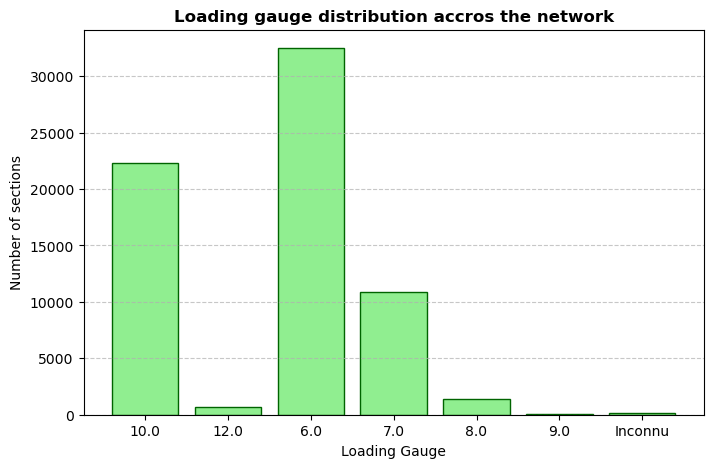

In [204]:
gabarits_du_reseau = []

for u, v, edge_data in G_final.edges(data=True):
    gauge = None
    
    if isinstance(edge_data, dict):
        if "loading_gauge" in edge_data:
            gauge = edge_data.get("loading_gauge")
        else:
            if edge_data.values():
                premier_element = list(edge_data.values())[0]
                if isinstance(premier_element, dict):
                    gauge = premier_element.get("loading_gauge")

    if gauge is not None:
        try:
            gauge_float = float(gauge)
            if gauge_float > 0:
                gabarits_du_reseau.append(gauge_float)
        except ValueError:
            gabarits_du_reseau.append(str(gauge))
    else:
        gabarits_du_reseau.append("Inconnu")

total_aretes = len(gabarits_du_reseau)
comptage = Counter(gabarits_du_reseau)


for gauge_name in sorted(comptage.keys(), key=lambda x: str(x)):
    nb = comptage[gauge_name]
    pourcentage = (nb / total_aretes) * 100
    print(f"Gabarit {str(gauge_name):<8} : {nb:<5} sections ({pourcentage:.1f}%)")

plt.figure(figsize=(8, 5))
keys_triees = sorted(comptage.keys(), key=lambda x: str(x))
values_triees = [comptage[k] for k in keys_triees]

plt.bar([str(k) for k in keys_triees], values_triees, color="lightgreen", edgecolor="darkgreen")
plt.title("Loading gauge distribution accros the network", fontsize=12, fontweight="bold")
plt.xlabel("Loading Gauge")
plt.ylabel("Number of sections")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [205]:
df_month_final['date_pure'] = pd.to_datetime(df_month_final['Datetime']).dt.date

vrai_nombre_trajets = df_month_final.groupby(['train_id', 'date_pure']).ngroups

print(f"Number of trains : {df_month_final['train_id'].nunique()}")
print(f"Number of journeys : {vrai_nombre_trajets}")

Number of trains : 5582
Number of journeys : 6544


## ===============================================
## Scenario : removal of bridge strike locations
## ===============================================

In [ ]:
trajets_trust_uniques = {}

stanox_to_node = {}
for node, data in G_final.nodes(data=True):
    stanox_attr = data.get("stanox")
    if stanox_attr is not None:
        stanox_clean = str(stanox_attr).strip().split(".")[0]
        if stanox_clean:
            stanox_to_node[stanox_clean] = node

print(f"Unique stations found in G_final : {len(stanox_to_node)}")

#Extract operational data

df_month_final["pure_date"] = pd.to_datetime(
    df_month_final["Datetime"]
).dt.date
df_sorted = df_month_final.sort_values(
    by=["train_id", "pure_date", "actual_timestamp"]
)

daily_trips = defaultdict(list)
for index, row in df_sorted.iterrows():
    u_stanox = row["loc_stanox"]
    if pd.notna(u_stanox):
        trip_key = (row["train_id"], row["pure_date"])
        stanox_clean = str(u_stanox).strip().split(".")[0]
        daily_trips[trip_key].append(stanox_clean)

for trip_key, stanox_list in daily_trips.items():
    origin_node = None
    destination_node = None

    for st in stanox_list:
        if st in stanox_to_node:
            origin_node = stanox_to_node[st]
            break

    for st in reversed(stanox_list):
        if st in stanox_to_node:
            destination_node = stanox_to_node[st]
            break

    if origin_node and destination_node and origin_node != destination_node:
        trajets_trust_uniques[trip_key] = (origin_node, destination_node)

Unique stations found in G_final : 1503


In [ ]:
edges_geom = []
edges_nodes = []

for u, v, data in G_final.edges(data=True):
    u_data = G_final.nodes[u]
    v_data = G_final.nodes[v]
    if all(k in u_data for k in ['lat', 'lon']) and all(k in v_data for k in ['lat', 'lon']):
        line = LineString([(float(u_data['lon']), float(u_data['lat'])), 
                           (float(v_data['lon']), float(v_data['lat']))])
        edges_geom.append(line)
        edges_nodes.append((u, v))

tree = STRtree(edges_geom)

bridge_points = [Point(lon, lat) for lon, lat in zip(df_strikes['Longitude'], df_strikes['Latitude'])]

closest_indices = tree.nearest(bridge_points)

u_list = [edges_nodes[idx][0] for idx in closest_indices]
v_list = [edges_nodes[idx][1] for idx in closest_indices]

df_strikes['closest_edge_u'] = u_list
df_strikes['closest_edge_v'] = v_list

In [ ]:
# from concurrent.futures import ProcessPoolExecutor
# import pandas as pd
# import networkx as nx


# # =====================================================
# # 1) Select top 300 bridge strike sections
# # =====================================================


# bridge_frequency = (
#     df_strikes
#     .groupby(['closest_edge_u','closest_edge_v'])
#     .size()
#     .reset_index(name="strike_frequency")
#     .sort_values(
#         "strike_frequency",
#         ascending=False
#     )
# )


# top_n = 300

# top_bridge_sections = bridge_frequency.head(top_n)


# print(
#     f"{len(top_bridge_sections)} bridge sections selected"
# )


# # =====================================================
# # 2) Baseline shortest paths
# # =====================================================


# G_gauge_6_initial = G_final.copy()

# G_gauge_10_initial = apply_gauge_10_restriction(
#     G_final
# )


# print("Computing baseline paths...")


# bridge_baseline = {
#     "GAUGE 6": {},
#     "GAUGE 10": {}
# }



# for gauge,graph in [
#     ("GAUGE 6",G_gauge_6_initial),
#     ("GAUGE 10",G_gauge_10_initial)
# ]:

#     for trip_id,(origin,destination) in trajets_trust_uniques.items():

#         try:

#             d0 = nx.shortest_path_length(
#                 graph,
#                 origin,
#                 destination,
#                 weight="distance"
#             )


#             t0 = nx.shortest_path_length(
#                 graph,
#                 origin,
#                 destination,
#                 weight="temps_minutes"
#             )


#             bridge_baseline[gauge][trip_id] = (
#                 origin,
#                 destination,
#                 d0,
#                 t0
#             )


#         except nx.NetworkXNoPath:
#             continue



# print(
#     "Gauge6:",
#     len(bridge_baseline["GAUGE 6"])
# )

# print(
#     "Gauge10:",
#     len(bridge_baseline["GAUGE 10"])
# )



# # =====================================================
# # 3) Single bridge scenario
# # =====================================================


# def run_single_bridge(args):


#     rank,row=args


#     u=row["closest_edge_u"]
#     v=row["closest_edge_v"]

#     frequency=row["strike_frequency"]


#     G6 = G_gauge_6_initial.copy()
#     G10 = G_gauge_10_initial.copy()



#     if G6.has_edge(u,v):

#         G6.remove_edge(u,v)


#     if G10.has_edge(u,v):

#         G10.remove_edge(u,v)



#     results=[]


#     for gauge,graph in [
#         ("GAUGE 6",G6),
#         ("GAUGE 10",G10)
#     ]:


#         intact=0
#         rerouted=0
#         blocked=0

#         total_distance=0
#         total_time=0


#         total=len(
#             bridge_baseline[gauge]
#         )


#         for trip_id,(origin,destination,d0,t0) in bridge_baseline[gauge].items():


#             try:


#                 d1 = nx.shortest_path_length(
#                     graph,
#                     origin,
#                     destination,
#                     weight="distance"
#                 )


#                 t1 = nx.shortest_path_length(
#                     graph,
#                     origin,
#                     destination,
#                     weight="temps_minutes"
#                 )


#                 distance_detour=d1-d0
#                 time_detour=t1-t0


#                 # small differences ignored

#                 if distance_detour <= 0.1 and time_detour <= 1:

#                     intact +=1


#                 else:

#                     rerouted +=1

#                     total_distance += max(
#                         0,
#                         distance_detour
#                     )

#                     total_time += max(
#                         0,
#                         time_detour
#                     )


#             except nx.NetworkXNoPath:

#                 blocked +=1



#         results.append({

#             "Bridge Rank":rank,

#             "edge_u":u,
#             "edge_v":v,

#             "u_lon":u[0],
#             "u_lat":u[1],

#             "v_lon":v[0],
#             "v_lat":v[1],

#             "strike_frequency":frequency,

#             "Gauge":gauge,

#             "Total trips":total,

#             "Intact trips":intact,

#             "Rerouted trips":rerouted,

#             "Blocked trips":blocked,


#             "Reroute rate":
#             rerouted/total,


#             "Blocked rate":
#             blocked/total,


#             "Avg detour (mi)":
#             total_distance/rerouted
#             if rerouted else 0,


#             "Avg delay (min)":
#             total_time/rerouted
#             if rerouted else 0

#         })


#     return results



# # =====================================================
# # 4) Parallel execution
# # =====================================================


# inputs=list(
#     enumerate(
#         top_bridge_sections.to_dict("records"),
#         start=1
#     )
# )



# print(
#     "Running bridge scenarios..."
# )


# bridge_results=[]


# with ProcessPoolExecutor(
#     max_workers=4
# ) as executor:


#     for result in executor.map(
#         run_single_bridge,
#         inputs
#     ):

#         bridge_results.extend(result)



# # =====================================================
# # 5) Save results
# # =====================================================


# df_bridge_results=pd.DataFrame(
#     bridge_results
# )


# print(
#     df_bridge_results.head()
# )


# df_bridge_results.to_csv(
#     "bridge_results_summary.csv",
#     index=False
# )


# print(
#     "Bridge analysis finished."
# )

In [ ]:
# for setup_name, indices in strike_setups.items():
#     if "Combined" in setup_name:
#         continue
        
#     print(f"\n {setup_name} (edges : {indices})")
    
#     for idx in indices:
#         if idx >= len(disrupted_edges):
#             continue
            
#         edge = disrupted_edges[idx]
#         u, v = edge[0], edge[1]
        
#         if G_final.has_edge(u, v):
#             if G_final.is_multigraph() and len(edge) >= 3:
#                 edge_data = G_final.get_edge_data(u, v, key=edge[2])
#             else:
#                 edge_data = G_final.get_edge_data(u, v)
            
#             line_name = edge_data.get('name', edge_data.get('line_name', 'Unknown Line'))
#             gauge_val = edge_data.get('loading_gauge', edge_data.get('loading_gauge', 'N/A'))
#             distance_val = edge_data.get('distance', 0.0)
            
#             stanox_u = G_final.nodes[u].get('stanox', 'N/A')
#             stanox_v = G_final.nodes[v].get('stanox', 'N/A')
            
#             print(f"  • Loading Gauge : {gauge_val}")
#         else:
#             print(f"No edge in the graph")

In [ ]:
# plt.clf()
# plt.close("all")

# pos = {node: (data.get("lon", 0), data.get("lat", 0)) for node, data in G_final.nodes(data=True)}
# x_nodes = [coords[0] for coords in pos.values()]
# y_nodes = [coords[1] for coords in pos.values()]

# x_strikes = df_strikes["Longitude"].tolist()
# y_strikes = df_strikes["Latitude"].tolist()

# indices_paires = [0, 2, 4, 6, 8]
# labels_rank = ["1st Worst", "2nd Worst", "3rd Worst", "4th Worst", "5th Worst"]
# colors_rank = ["#FF0000", "#FF4500", "#FF8C00", "#FFA500", "#FFD700"]

# top_5_points = []
# for rank, idx in enumerate(indices_paires):
#     if idx < len(disrupted_edges):
#         edge = disrupted_edges[idx]
#         u, v = edge[0], edge[1]
        
#         match = df_strikes[(df_strikes['closest_edge_u'] == u) & (df_strikes['closest_edge_v'] == v)]
#         if not match.empty:
#             lon = match.iloc[0]["Longitude"]
#             lat = match.iloc[0]["Latitude"]
#         elif u in pos and v in pos:
#             lon = (pos[u][0] + pos[v][0]) / 2
#             lat = (pos[u][1] + pos[v][1]) / 2
#         else:
#             continue
            
#         top_5_points.append((lon, lat, labels_rank[rank], colors_rank[rank]))

# fig, ax = plt.subplots(figsize=(12, 10), dpi=300)

# ax.scatter(x_nodes, y_nodes, s=1, color="#D3D3D3", alpha=0.3)
# ax.scatter(x_strikes, y_strikes, s=2, color="#4A5B6D", alpha=0.15, marker="o")

# custom_offsets = {
#     0: (0.00, 0.22, 'bottom'),   
#     1: (0.00, -0.22, 'top'),     
#     2: (0.12, 0.05, 'center'),   
#     3: (0.12, 0.00, 'center'),   
#     4: (0.12, -0.10, 'center')   
# }

# for rank, (lon, lat, label, color) in enumerate(top_5_points):
#     plot_lon, plot_lat = lon, lat
#     if rank == 0:     
#         plot_lon -= 0.04  
#         plot_lat += 0.05  
#     elif rank == 1:   
#         plot_lon += 0.04  
#         plot_lat -= 0.05  

#     ax.scatter(
#         plot_lon, plot_lat,
#         color=color,
#         s=160, 
#         edgecolors="black",
#         linewidths=1.5,
#         zorder=20
#     )
    
#     dx, dy, va_dir = custom_offsets[rank]
#     ha_dir = 'center' if dx == 0.00 else ('left' if dx > 0 else 'right')
        
#     ax.text(
#         plot_lon + dx,
#         plot_lat + dy,
#         label,
#         fontsize=9,
#         fontweight="bold",
#         color="black",
#         zorder=25,
#         va=va_dir,
#         ha=ha_dir,
#         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.3')
#     )


# min_lon, max_lon = min(x_nodes), max(x_nodes)
# min_lat, max_lat = min(y_nodes), max(y_nodes)

# leg_x = min_lon + (max_lon - min_lon) * 0.64
# leg_y = min_lat + (max_lat - min_lat) * 0.75
# box_width = (max_lon - min_lon) * 0.33  
# box_height = (max_lat - min_lat) * 0.19

# bg_box = mpatches.Rectangle(
#     (leg_x, leg_y), box_width, box_height,
#     facecolor="white", 
#     edgecolor="#A0A0A0", 
#     linewidth=1.2, 
#     zorder=28
# )
# ax.add_patch(bg_box)

# legend_elements = [
#     plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#D3D3D3", markersize=6, label="UK Rail Network"),
#     plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#4A5B6D", markersize=5, label="Historical Strikes")
# ]

# leg = ax.legend(
#     handles=legend_elements, 
#     loc="upper left",
#     bbox_to_anchor=(leg_x + box_width*0.06, leg_y + box_height*0.90),
#     bbox_transform=ax.transData,
#     fontsize=10, 
#     frameon=False
# )
# leg.set_zorder(30)

# cmap_top5 = mcolors.LinearSegmentedColormap.from_list("top5_gradient", colors_rank)
# norm = mcolors.Normalize(vmin=1, vmax=5)

# cax = ax.inset_axes([leg_x + box_width*0.15, leg_y + box_height*0.24, box_width*0.70, box_height*0.09], transform=ax.transData)
# cax.set_zorder(29)

# cb = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap_top5), cax=cax, orientation='horizontal')

# cb.set_ticks([1, 5])
# cb.set_ticklabels(['1st Worst', '5th Worst'], fontsize=9, fontweight="bold")
# cb.ax.tick_params(size=0, pad=5)

# cax.set_title("Top 5 Bridge Strikes", fontsize=9.5, pad=6, loc="left")

# ax.set_title("Graph representation of the top 5 most frequent bridge strikes", fontsize=14, fontweight="bold", pad=20)
# ax.axis("off")

# ax.set_xlim(min_lon - 0.5, max_lon + 0.5)
# ax.set_ylim(min_lat - 0.5, max_lat + 0.5)

# plt.show()

## ===============================================
## Scenario : removal of a freight hub
## ===============================================

In [ ]:
# node_counts = Counter(df_month_final['loc_stanox'].dropna())

# #High-flow inland hub

# inland_node = None
# inland_name = "Unknown inland hub"
# inland_flow = 0

# most_common_stanox, _ = node_counts.most_common(1)[0]

# for node, data in G_final.nodes(data=True):
#     if (node == most_common_stanox or data.get('stanox') == most_common_stanox or data.get('id') == most_common_stanox):
#         if isinstance(node, tuple) and len(node)==2:
#             if not is_coastal_node(node):

#                 inland_node = node
#                 inland_flow = node_counts[most_common_stanox]

#                 inland_name = data.get('name', f"STANOX {most_common_stanox}")
#                 break




# #High-flow Maritime hub


# maritime_node = None
# maritime_name = "Unknown coastal port"
# maritime_flow = 0


# for stanox, count in node_counts.most_common():
#     for node, data in G_final.nodes(data=True):
#         if (node == stanox or data.get('stanox') == stanox or data.get('id') == stanox):
#             if is_coastal_node(node):
#                 if count > maritime_flow:

#                     maritime_flow = count
#                     maritime_node = node
#                     maritime_name = data.get('name', f"STANOX {stanox}")



# #Low-flow maritime hub

# low_flow_node = None
# low_flow_name = "Unknown low flow port"
# low_flow = float("inf")

# for stanox, count in sorted(node_counts.items(), key=lambda x:x[1]):
#     for node, data in G_final.nodes(data=True):
#         if (node == stanox or data.get('stanox') == stanox or data.get('id') == stanox):
#             if is_coastal_node(node):
#                 if count >= 10 and count < low_flow:

#                     low_flow = count
#                     low_flow_node = node
#                     low_flow_name = data.get('name', f"STANOX {stanox}")
                    

# print("\nSelected disruption locations:")
# print("High-flow inland:", inland_name, "| Flow:", inland_flow)
# print("High-flow coastal:", maritime_name, "| Flow:", maritime_flow)
# print("Low-flow coastal:", low_flow_name, "| Flow:", low_flow)

# #Define scenarios

# scenarios = [
#     {"type":"High-flow inland freight hub", "node":inland_node, "name":inland_name},
#     {"type":"High-flow coastal freight hub", "node":maritime_node, "name":maritime_name},
#     {"type":"Low-flow coastal port", "node":low_flow_node, "name":low_flow_name}
# ]

# #Baseline
# G6_initial = G_final.copy()
# G10_initial = apply_gauge_10_restriction(G_final)
# results_all = []

# for sc in scenarios:
#     print("\n", sc["type"], sc["name"])
#     target_node = sc["node"]

#     if target_node is None:
#         continue

#     G6_disc = G_final.copy()

#     if G6_disc.is_multigraph():
#         edges_removed = list(G6_disc.edges(target_node, keys=True))
#         for u,v,k in edges_removed:
#             G6_disc.remove_edge(u,v,k)
#     else:
#         edges_removed = list(G6_disc.edges(target_node))
#         G6_disc.remove_edges_from(edges_removed)


#     G10_disc = apply_gauge_10_restriction(G6_disc)

#     metrics = {

#         "Gauge 6":{
#             "ok":0,
#             "reroutes":0,
#             "blocked":0,
#             "dist":0,
#             "time":0
#         },

#         "Gauge 10":{
#             "ok":0,
#             "reroutes":0,
#             "blocked":0,
#             "dist":0,
#             "time":0
#         }
#     }

#     gauge6_total = 0
#     gauge10_total = 0

#     for travel_id, (origin, destination) in trajets_trust_uniques.items():
#     #Loading gauge 6
#         try:
#             d0_6 = nx.shortest_path_length(G6_initial, origin, destination, weight="distance")
#             t0_6 = nx.shortest_path_length(G6_initial, origin, destination, weight="temps_minutes")
#             gauge6_total += 1

#         except nx.NetworkXNoPath:
#             continue



#         try:
#             d = nx.shortest_path_length(G6_disc, origin, destination, weight="distance")
#             t = nx.shortest_path_length(G6_disc, origin, destination, weight="temps_minutes")
#             if abs(d - d0_6) <= 0.1 and abs(t - t0_6) <= 1:
#                 metrics["Gauge 6"]["ok"] += 1
#             else:
#                 metrics["Gauge 6"]["reroutes"] += 1
#                 metrics["Gauge 6"]["dist"] += (d - d0_6)
#                 metrics["Gauge 6"]["time"] += (t - t0_6)

#         except nx.NetworkXNoPath:
#             metrics["Gauge 6"]["blocked"] += 1


#         #Loading gauge 10
#         try:
#             d0_10 = nx.shortest_path_length(G10_initial, origin, destination, weight="distance")
#             t0_10 = nx.shortest_path_length(G10_initial, origin, destination, weight="temps_minutes")
#             gauge10_total += 1

#         except nx.NetworkXNoPath:
#             continue

#         try:
#             d = nx.shortest_path_length(G10_disc, origin, destination, weight="distance")
#             t = nx.shortest_path_length(G10_disc, origin, destination, weight="temps_minutes")
#             if abs(d - d0_10) <= 0.1 and abs(t - t0_10) <= 1:
#                 metrics["Gauge 10"]["ok"] += 1
#             else:
#                 metrics["Gauge 10"]["reroutes"] += 1
#                 metrics["Gauge 10"]["dist"] += (d - d0_10)
#                 metrics["Gauge 10"]["time"] += (t - t0_10)

#         except nx.NetworkXNoPath:
#             metrics["Gauge 10"]["blocked"] += 1

# #Results

#     for gauge,total in [("Gauge 6",gauge6_total), ("Gauge 10",gauge10_total)]:
#         if total == 0:
#             continue

#         reroute_number = max(1, metrics[gauge]["reroutes"])

#         results_all.append({
#             "Scenario":sc["type"],
#             "Location":sc["name"],
#             "Gauge":gauge,
#             "Intact Trips": f'{metrics[gauge]["ok"]} ' f'({metrics[gauge]["ok"]/total*100:.1f}%)',
#             "Rerouted Trips": f'{metrics[gauge]["reroutes"]} ' f'({metrics[gauge]["reroutes"]/total*100:.1f}%)',
#             "Blocked Trips": f'{metrics[gauge]["blocked"]} ' f'({metrics[gauge]["blocked"]/total*100:.1f}%)',
#             "Avg Detour (mi)": f'{metrics[gauge]["dist"]/reroute_number:.2f}',
#             "Avg Delay (min)": f'{metrics[gauge]["time"]/reroute_number:.1f}'
#         })

# df_freight_hub_results = pd.DataFrame(results_all)
# print(df_freight_hub_results.to_string(index=False))
# df_freight_hub_results.to_csv("hubs_results_summary.csv", index=False)

In [ ]:
# plt.clf()
# plt.close("all")

# pos = {node: (data.get("lon", 0), data.get("lat", 0)) for node, data in G_final.nodes(data=True)}
# x_nodes = [coords[0] for coords in pos.values()]
# y_nodes = [coords[1] for coords in pos.values()]

# base_lines = []
# for u, v in G_final.edges():
#     if u in pos and v in pos:
#         base_lines.append([pos[u], pos[v]])

# hubs_to_plot = []

# hubs_config = [
#     {
#         "node": inland_node, 
#         "name": inland_name, 
#         "label": "High-Flow Inland Hub", 
#         "dx": 0.15, "dy": 0.05, "ha": "left", "va": "center"
#     },
#     {
#         "node": maritime_node, 
#         "name": maritime_name, 
#         "label": "High-Flow Maritime Hub", 
#         "dx": 0.15, "dy": -0.05, "ha": "left", "va": "center"
#     },
#     {
#         "node": low_flow_node, 
#         "name": low_flow_name, 
#         "label": "Low-Flow Maritime Hub", 
#         "dx": -0.15, "dy": 0.00, "ha": "right", "va": "center"
#     }
# ]

# for cfg in hubs_config:
#     node = cfg["node"]
#     if node is not None and node in pos:
#         lon, lat = pos[node]
#         hubs_to_plot.append({
#             "lon": lon,
#             "lat": lat,
#             "name": cfg["name"],
#             "label": cfg["label"],
#             "dx": cfg["dx"],
#             "dy": cfg["dy"],
#             "ha": cfg["ha"],
#             "va": cfg["va"]
#         })


# fig, ax = plt.subplots(figsize=(12, 11), dpi=300, facecolor="white")
# ax.set_facecolor("white")

# lc_base = LineCollection(base_lines, colors="#E5E8E8", linewidths=0.4, alpha=0.6, zorder=1)
# ax.add_collection(lc_base)
# ax.scatter(x_nodes, y_nodes, s=0.3, color="#BDC3C7", alpha=0.3, zorder=2)

# for hub in hubs_to_plot:
#     ax.scatter(
#         hub["lon"], hub["lat"],
#         color="#E74C3C",
#         s=130, 
#         edgecolors="#FFFFFF",
#         linewidths=1.5,
#         zorder=100
#     )
    
#     ax.text(
#         hub["lon"] + hub["dx"], 
#         hub["lat"] + hub["dy"],
#         f"{hub['label']}",
#         fontsize=8.5,
#         fontweight="bold",
#         color="#2C3E50",
#         zorder=120,
#         va=hub["va"],
#         ha=hub["ha"],
#         bbox=dict(
#             facecolor='white', 
#             alpha=0.9, 
#             edgecolor='#BDC3C7', 
#             boxstyle='round,pad=0.35', 
#             linewidth=0.8
#         )
#     )

# min_lon, max_lon = min(x_nodes), max(x_nodes)
# min_lat, max_lat = min(y_nodes), max(y_nodes)

# leg_x = min_lon + (max_lon - min_lon) * 0.60
# leg_y = min_lat + (max_lat - min_lat) * 0.76
# box_width = (max_lon - min_lon) * 0.23  
# box_height = (max_lat - min_lat) * 0.12

# bg_box = mpatches.Rectangle(
#     (leg_x, leg_y), box_width, box_height,
#     facecolor="#F8F9F9", 
#     edgecolor="#BDC3C7", 
#     linewidth=1.2, 
#     zorder=130
# )
# ax.add_patch(bg_box)

# legend_elements = [
#     plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#E74C3C", markeredgecolor="#FFFFFF", markersize=9, label="Selected Freight Hubs"),
#     plt.Line2D([0], [0], color="#E0E0E0", linewidth=1.5, label="UK Rail Network")
# ]

# leg = ax.legend(
#     handles=legend_elements, 
#     loc="upper left",
#     bbox_to_anchor=(leg_x + box_width*0.05, leg_y + box_height*0.82),
#     bbox_transform=ax.transData,
#     fontsize=9.5, 
#     frameon=False
# )
# for text in leg.get_texts():
#     text.set_color("#2C3E50")
# leg.set_zorder(140)


# title = ax.set_title("Selected Freight Hubs for Vulnerability Analysis", fontsize=13, fontweight="bold", pad=25)
# title.set_color("#2C3E50")
# ax.axis("off")

# ax.set_xlim(min_lon - 0.2, max_lon + 0.2)
# ax.set_ylim(min_lat - 0.2, max_lat + 0.2)

# plt.show()

## ===============================================
## Scenario : removal depending on the flow
## ===============================================

In [ ]:
# from collections import Counter
# from concurrent.futures import ProcessPoolExecutor


# # =====================================================
# # 1) Compute freight flow on each railway section
# # =====================================================

# edge_traffic = Counter()

# print("Computing freight flows...")


# for voyage_id, (origin, destination) in trajets_trust_uniques.items():

#     try:

#         path = nx.shortest_path(
#             G_final,
#             source=origin,
#             target=destination,
#             weight="distance"
#         )

#         for i in range(len(path)-1):

#             edge_key = tuple(sorted([path[i], path[i+1]]))
#             edge_traffic[edge_key] += 1


#     except nx.NetworkXNoPath:
#         continue



# # =====================================================
# # Select top 300 highest-flow sections
# # =====================================================


# top_n = 300

# top_flow_sections = edge_traffic.most_common(top_n)


# print(
#     f"\nTop {top_n} strategic-flow sections selected"
# )



# for rank, (edge,count) in enumerate(top_flow_sections[:10],1):

#     node_a,node_b = edge

#     name_a = G_final.nodes[node_a].get(
#         "name",
#         str(node_a)
#     )

#     name_b = G_final.nodes[node_b].get(
#         "name",
#         str(node_b)
#     )

#     print(
#         f"#{rank}: {name_a} - {name_b} | "
#         f"{count} trains "
#         f"({count/len(trajets_trust_uniques)*100:.1f}%)"
#     )




# # =====================================================
# # 2) Compute baseline shortest paths once
# # =====================================================


# G_gauge_6_initial = G_final.copy()


# G_gauge_10_initial = apply_gauge_10_restriction(
#     G_final
# )



# print("\nComputing baseline shortest paths...")


# baseline_results = {

#     "Gauge 6": {},

#     "Gauge 10": {}

# }



# for gauge,graph in [

#     ("Gauge 6",G_gauge_6_initial),

#     ("Gauge 10",G_gauge_10_initial)

# ]:


#     for trip_id,(origin,destination) in trajets_trust_uniques.items():


#         try:


#             d = nx.shortest_path_length(
#                 graph,
#                 source=origin,
#                 target=destination,
#                 weight="distance"
#             )


#             t = nx.shortest_path_length(
#                 graph,
#                 source=origin,
#                 target=destination,
#                 weight="temps_minutes"
#             )



#             baseline_results[gauge][trip_id] = (

#                 origin,
#                 destination,
#                 d,
#                 t

#             )


#         except nx.NetworkXNoPath:

#             continue



# print(
#     "Baseline Gauge6:",
#     len(baseline_results["Gauge 6"])
# )


# print(
#     "Baseline Gauge10:",
#     len(baseline_results["Gauge 10"])
# )





# # =====================================================
# # 3) Function : one flow disruption scenario
# # =====================================================


# def run_single_flow_scenario(args):


#     rank, edge, flow = args


#     u,v=edge


#     G6 = G_gauge_6_initial.copy()

#     G10 = G_gauge_10_initial.copy()



#     if G6.has_edge(u,v):

#         G6.remove_edge(u,v)



#     if G10.has_edge(u,v):

#         G10.remove_edge(u,v)





#     metrics={


#         "Gauge 6":{

#             "intact":0,
#             "rerouted":0,
#             "blocked":0,
#             "distance":0,
#             "time":0

#         },


#         "Gauge 10":{

#             "intact":0,
#             "rerouted":0,
#             "blocked":0,
#             "distance":0,
#             "time":0

#         }

#     }




#     for gauge,graph in [


#         ("Gauge 6",G6),

#         ("Gauge 10",G10)

#     ]:


#         for trip_id,(origin,destination,d0,t0) in baseline_results[gauge].items():


#             try:


#                 d1 = nx.shortest_path_length(

#                     graph,

#                     source=origin,

#                     target=destination,

#                     weight="distance"

#                 )


#                 t1 = nx.shortest_path_length(

#                     graph,

#                     source=origin,

#                     target=destination,

#                     weight="temps_minutes"

#                 )



#                 distance_detour = d1-d0

#                 time_detour = t1-t0




#                 if distance_detour < 0.1 and time_detour < 1:


#                     metrics[gauge]["intact"] += 1



#                 else:


#                     metrics[gauge]["rerouted"] += 1


#                     metrics[gauge]["distance"] += max(
#                         0,
#                         distance_detour
#                     )


#                     metrics[gauge]["time"] += max(
#                         0,
#                         time_detour
#                     )



#             except nx.NetworkXNoPath:


#                 metrics[gauge]["blocked"] += 1





#     results=[]



#     for gauge in ["Gauge 6","Gauge 10"]:


#         total = len(
#             baseline_results[gauge]
#         )


#         rerouted = metrics[gauge]["rerouted"]


#         results.append({

#             "Section rank":rank,

#             "Edge u":str(u),

#             "Edge v":str(v),


#             "Longitude u":u[0],

#             "Latitude u":u[1],


#             "Longitude v":v[0],

#             "Latitude v":v[1],


#             "Flow trains":flow,


#             "Gauge":gauge,


#             "Trips analysed":total,



#             "Intact Trips":
#             f"{metrics[gauge]['intact']} "
#             f"({metrics[gauge]['intact']/total*100:.1f}%)"
#             if total > 0 else "0",



#             "Rerouted Trips":
#             f"{rerouted} "
#             f"({rerouted/total*100:.1f}%)"
#             if total > 0 else "0",



#             "Blocked Trips":
#             f"{metrics[gauge]['blocked']} "
#             f"({metrics[gauge]['blocked']/total*100:.1f}%)"
#             if total > 0 else "0",



#             "Avg Detour (mi)":
#             f"{metrics[gauge]['distance']/rerouted:.2f}"
#             if rerouted > 0 else "0",



#             "Avg Delay (min)":
#             f"{metrics[gauge]['time']/rerouted:.1f}"
#             if rerouted > 0 else "0"


#         })



#     return results






# # =====================================================
# # 4) Parallel execution
# # =====================================================


# print("\nRunning 300 flow disruption scenarios...")



# scenario_inputs=[


#     (
#         rank+1,
#         edge,
#         count

#     )

#     for rank,(edge,count)

#     in enumerate(top_flow_sections)

# ]



# all_results=[]



# with ProcessPoolExecutor(
#     max_workers=8
# ) as executor:


#     for result in executor.map(
#         run_single_flow_scenario,
#         scenario_inputs
#     ):


#         all_results.extend(result)





# # =====================================================
# # 5) Save results
# # =====================================================


# df_flow_results = pd.DataFrame(
#     all_results
# )



# print(
#     df_flow_results.to_string(index=False)
# )



# df_flow_results.to_csv(
#     "flow_results_summary_300.csv",
#     index=False
# )



# print(
#     "\nFlow analysis finished."
# )

In [ ]:
from collections import Counter
from concurrent.futures import ProcessPoolExecutor


# =====================================================
# 1) Compute freight flow on each railway edge
# =====================================================

edge_traffic = Counter()

print("Computing freight flows...")


for voyage_id, (origin, destination) in trajets_trust_uniques.items():

    try:

        path = nx.shortest_path(
            G_final,
            source=origin,
            target=destination,
            weight="distance"
        )

        for i in range(len(path)-1):

            edge_key = tuple(sorted([path[i], path[i+1]]))
            edge_traffic[edge_key] += 1


    except nx.NetworkXNoPath:

        continue



# =====================================================
# 2) Build continuous flow sections
# =====================================================

target_sections = 300


def build_flow_sections(edge_traffic, target_sections):

    """
    Group adjacent edges having exactly the same freight flow.
    No threshold, no approximation.
    """

    unused_edges = set(edge_traffic.keys())

    sorted_edges = sorted(
        unused_edges,
        key=lambda e: edge_traffic[e],
        reverse=True
    )


    sections = []


    for starting_edge in sorted_edges:


        if starting_edge not in unused_edges:
            continue


        flow = edge_traffic[starting_edge]


        section = [starting_edge]


        unused_edges.remove(starting_edge)


        expanded = True


        while expanded:

            expanded = False


            current_edges = list(section)


            for current_edge in current_edges:


                shared_nodes = set(current_edge)


                for candidate in list(unused_edges):


                    candidate_flow = edge_traffic[candidate]


                    # EXACT SAME FLOW ONLY
                    if candidate_flow != flow:
                        continue


                    # Must share one node
                    if shared_nodes.intersection(candidate):


                        section.append(candidate)

                        unused_edges.remove(candidate)

                        expanded = True


        sections.append(
            (
                section,
                flow
            )
        )


        if len(sections) >= target_sections:

            break



    return sections




flow_sections = build_flow_sections(
    edge_traffic,
    target_sections
)



print(
    f"\nRequested sections: {target_sections}"
)


print(
    f"Created sections: {len(flow_sections)}"
)


if len(flow_sections) < target_sections:

    print(
        "WARNING: Less sections available than requested. "
        "All available sections will be analysed."
    )



for rank, (section, flow) in enumerate(flow_sections[:10],1):


    print(
        f"\nSection #{rank}"
    )

    print(
        f"Number of edges: {len(section)}"
    )

    print(
        f"Flow: {flow} trains"
    )




# =====================================================
# 3) Compute baseline shortest paths once
# =====================================================


G_gauge_6_initial = G_final.copy()


G_gauge_10_initial = apply_gauge_10_restriction(
    G_final
)



print("\nComputing baseline shortest paths...")


baseline_results = {

    "Gauge 6": {},

    "Gauge 10": {}

}



for gauge, graph in [

    ("Gauge 6", G_gauge_6_initial),

    ("Gauge 10", G_gauge_10_initial)

]:


    for trip_id, (origin, destination) in trajets_trust_uniques.items():


        try:


            d = nx.shortest_path_length(
                graph,
                source=origin,
                target=destination,
                weight="distance"
            )


            t = nx.shortest_path_length(
                graph,
                source=origin,
                target=destination,
                weight="temps_minutes"
            )


            baseline_results[gauge][trip_id] = (

                origin,
                destination,
                d,
                t

            )


        except nx.NetworkXNoPath:

            continue



print(
    "Baseline Gauge6:",
    len(baseline_results["Gauge 6"])
)


print(
    "Baseline Gauge10:",
    len(baseline_results["Gauge 10"])
)

In [ ]:
# =====================================================
# 4) Function : one flow section disruption scenario
# =====================================================


def run_single_flow_scenario(args):


    rank, section_edges, flow = args


    G6 = G_gauge_6_initial.copy()

    G10 = G_gauge_10_initial.copy()



    # Remove all edges belonging to the disrupted section

    for u, v in section_edges:


        if G6.has_edge(u, v):

            G6.remove_edge(u, v)



        if G10.has_edge(u, v):

            G10.remove_edge(u, v)





    metrics={


        "Gauge 6":{

            "intact":0,
            "rerouted":0,
            "blocked":0,
            "distance":0,
            "time":0

        },


        "Gauge 10":{

            "intact":0,
            "rerouted":0,
            "blocked":0,
            "distance":0,
            "time":0

        }

    }




    for gauge, graph in [


        ("Gauge 6", G6),

        ("Gauge 10", G10)

    ]:


        for trip_id, (origin, destination, d0, t0) in baseline_results[gauge].items():


            try:


                d1 = nx.shortest_path_length(

                    graph,

                    source=origin,

                    target=destination,

                    weight="distance"

                )



                t1 = nx.shortest_path_length(

                    graph,

                    source=origin,

                    target=destination,

                    weight="temps_minutes"

                )



                distance_detour = d1 - d0

                time_detour = t1 - t0




                if distance_detour < 0.1 and time_detour < 1:


                    metrics[gauge]["intact"] += 1



                else:


                    metrics[gauge]["rerouted"] += 1


                    metrics[gauge]["distance"] += max(
                        0,
                        distance_detour
                    )


                    metrics[gauge]["time"] += max(
                        0,
                        time_detour
                    )



            except nx.NetworkXNoPath:


                metrics[gauge]["blocked"] += 1





    results=[]



    for gauge in ["Gauge 6", "Gauge 10"]:


        total = len(
            baseline_results[gauge]
        )


        rerouted = metrics[gauge]["rerouted"]



        results.append({


            "Section rank": rank,


            "Number of disrupted edges": len(section_edges),


            "Disrupted edges": str(section_edges),


            "Flow trains": flow,


            "Gauge": gauge,


            "Trips analysed": total,



            "Intact Trips":

            f"{metrics[gauge]['intact']} "
            f"({metrics[gauge]['intact']/total*100:.1f}%)"

            if total > 0 else "0",



            "Rerouted Trips":

            f"{rerouted} "
            f"({rerouted/total*100:.1f}%)"

            if total > 0 else "0",



            "Blocked Trips":

            f"{metrics[gauge]['blocked']} "
            f"({metrics[gauge]['blocked']/total*100:.1f}%)"

            if total > 0 else "0",



            "Avg Detour (mi)":

            f"{metrics[gauge]['distance']/rerouted:.2f}"

            if rerouted > 0 else "0",



            "Avg Delay (min)":

            f"{metrics[gauge]['time']/rerouted:.1f}"

            if rerouted > 0 else "0"


        })



    return results







# =====================================================
# 5) Parallel execution
# =====================================================


print(
    "\nRunning flow section disruption scenarios..."
)



scenario_inputs = [


    (

        rank + 1,

        section,

        flow

    )


    for rank, (section, flow)

    in enumerate(flow_sections)

]



print(
    f"Total scenarios: {len(scenario_inputs)}"
)



all_results=[]



with ProcessPoolExecutor(
    max_workers=8
) as executor:


    for result in executor.map(
        run_single_flow_scenario,
        scenario_inputs
    ):


        all_results.extend(result)







# =====================================================
# 6) Save results
# =====================================================


df_flow_results = pd.DataFrame(
    all_results
)



print(
    df_flow_results.to_string(index=False)
)



df_flow_results.to_csv(
    "flow_results_summary_sections.csv",
    index=False
)



print(
    "\nFlow section analysis finished."
)